Постановка задачи:

Есть обыкновенное дифференциальное уравнение первого порядка, разрешенное относительно производной $\frac{dy}{dt} = \lambda y$, где $\lambda = -1$.

Решением этого уравнения будет считаться функция (функции) $y = y(t)$, обращающая приведенное выше выражение в тождество на отрезке $[a,b]$ 

### Решим его $методом \ Эйлера$ $(метод \ степенных \ рядов)$



In [1]:
"""
Для постановки задачи Коши нам необходимо какое-то начальное значение, сделаем его выбор произвольным, но
для определенности зафиксируем конкретное.
"""

y0 = 15
Lambda = -5


In [2]:
"""
Зададим произвольный отрезок [a, b], однако, все же, зафиксируем границы (для определенности)
"""

a = -100
b = 10

In [3]:
"""
Создадим функцию разбиения промежутка [a,b] на N интервалов
"""

def grid(a, b, N):
    h = (b - a)/N
    grid = [a + i*h for i in range(N + 1)]
    return grid, h


In [4]:
"""
Напишем функцию нахождения значения y_{j+1} приближенного решения в точке t_{j+1} = t_{j} + h
"""

def power_series_method_1(t, y, h, f): #локальная погрешность O(h^2)
    return y + h*f(t, y)

In [5]:
"""
Для двух следующих функций потребуется так же написать функции производной
"""

def f(t, y):
    return Lambda * y

def f_t(t, y):
    return 0.0

def f_y(t, y):
    return Lambda

def f_tt(t, y):
    return 0.0

def f_ty(t, y):
    return 0.0

def f_yy(t, y):
    return 0.0



In [6]:
"""
Напишем теперь функции нахождения значения y_{j+1} с большими порядками точности
"""


def power_series_method_2(t, y, h, f): #локальная погрешность O(h^3)
    F = f(t, y)
    y2 = f_t(t, y) + F * f_y(t, y)         
    return y + h * F + (h**2) / 2.0 * y2


# def power_series_method_3(t, y, h, f): #локальная погрешность O(h^4)
#     F = f(t, y)
#     ft = f_t(t, y)
#     fy = f_y(t, y)

#     y2 = ft + F * fy


#     y3 = (
#         f_tt(t, y)
#         + 2.0 * F * f_ty(t, y)
#         + ft * fy
#         + F * (fy**2)
#         + (F**2) * f_yy(t, y)
#     )

#     return y + h * F + (h**2) / 2.0 * y2 + (h**3) / 6.0 * y3

def power_series_method_3(t, y, h, f):
    z = h * Lambda
    return y * (1 + z + z**2 / 2 + z**3 / 6)


In [7]:
"""
Импортируем библиотеку для отрисовки графиков, а также Numpy
"""

import matplotlib.pyplot as plt
import numpy as np

Ну и найдем непосредственно аналитическое решение нашего дифференциального уравнения

$$\frac{dy}{dt} = \lambda y \Longrightarrow \frac{dy}{y} = \lambda dt \Longrightarrow \int_{y(t_0)}^{y(t)} 
\frac{dy}{y} = \int_{t_0}^{t} \lambda dx \Longrightarrow ln|y(t)| \mid_{y(t_0)}^{y(t)} = $$
$$ = \lambda (t - t_0) \Longrightarrow 
ln|y(t)| - ln|y(t_0)| = \lambda t - \lambda t_0 \Longrightarrow ln|y| = $$
$$ = \lambda t - C \Longrightarrow |y| = e^{\lambda t + C}
= e^C e^{\lambda t} = C e^{\lambda t} \Longrightarrow y = C e^{\lambda t}$$
$$C \in \mathbb{R}$$

Таким образом $C = \frac{y}{e^{\lambda t}}$

In [8]:
"""
Напишем функцию аналитического решения, учитывая нашу начальную задачу
"""

# def analytic_solution(y0, Lambda, t0, t):
#     C = y0 * np.exp(-Lambda * t0)
#     return C * np.exp(Lambda * t)

def analytic_solution(C, Lambda, t0, t):
    return C * np.exp(Lambda * (t - t0))

In [9]:
"""
Зададим теперь сетку и пустой массив для отрисовки значений
"""
N = 10000

values_1 = [y0]
values_2 = [y0]
values_3 = [y0]
values_analytic = [y0]

domain, h = grid(a, b, N)

f = lambda t, y: Lambda * y

for t in range(1, len(domain)):
    values_1.append(power_series_method_1(domain[t-1], values_1[t-1], h, f))
    values_2.append(power_series_method_2(domain[t-1], values_2[t-1], h, f))
    values_3.append(power_series_method_3(domain[t-1], values_3[t-1], h, f))
    values_analytic.append(analytic_solution(values_analytic[0], Lambda, domain[0], domain[t]))

print(domain)

print(values_1)
print(values_2)
print(values_3)
print(values_analytic)



[-100.0, -99.989, -99.978, -99.967, -99.956, -99.945, -99.934, -99.923, -99.912, -99.901, -99.89, -99.879, -99.868, -99.857, -99.846, -99.835, -99.824, -99.813, -99.802, -99.791, -99.78, -99.769, -99.758, -99.747, -99.736, -99.725, -99.714, -99.703, -99.692, -99.681, -99.67, -99.659, -99.648, -99.637, -99.626, -99.615, -99.604, -99.593, -99.582, -99.571, -99.56, -99.549, -99.538, -99.527, -99.516, -99.505, -99.494, -99.483, -99.472, -99.461, -99.45, -99.439, -99.428, -99.417, -99.406, -99.395, -99.384, -99.373, -99.362, -99.351, -99.34, -99.329, -99.318, -99.307, -99.296, -99.285, -99.274, -99.263, -99.252, -99.241, -99.23, -99.219, -99.208, -99.197, -99.186, -99.175, -99.164, -99.153, -99.142, -99.131, -99.12, -99.109, -99.098, -99.087, -99.076, -99.065, -99.054, -99.043, -99.032, -99.021, -99.01, -98.999, -98.988, -98.977, -98.966, -98.955, -98.944, -98.933, -98.922, -98.911, -98.9, -98.889, -98.878, -98.867, -98.856, -98.845, -98.834, -98.823, -98.812, -98.801, -98.79, -98.779, -98.

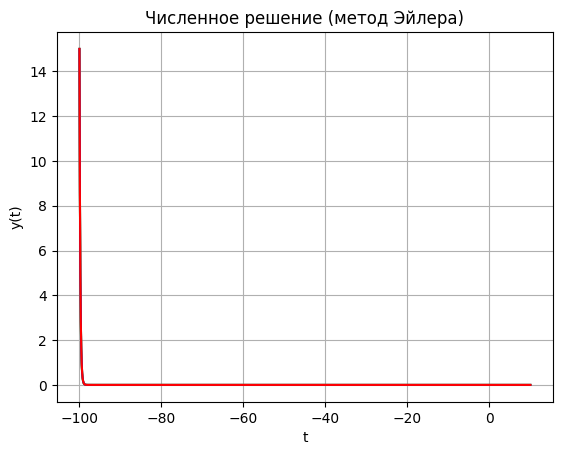

In [10]:
plt.figure()
plt.plot(domain, values_1, color = 'green')
plt.plot(domain, values_2, color = 'yellow')
plt.plot(domain, values_3, color = 'blue')
plt.plot(domain, values_analytic, color = 'red')
plt.xlabel("t")
plt.ylabel("y(t)")
plt.title("Численное решение (метод Эйлера)")
plt.grid(True)
plt.show()

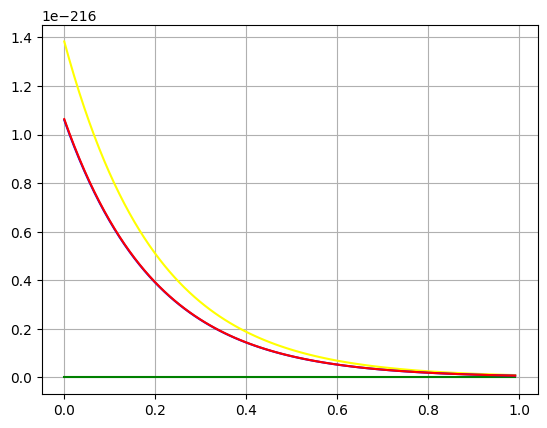

In [11]:
"""
Рассмотрим конкретный промежуток, чтобы было лучше видно графики
"""

mask = [0 <= t <= 1 for t in domain]

domain_zoom = [t for t, m in zip(domain, mask) if m]
v1_zoom = [v for v, m in zip(values_1, mask) if m]
v2_zoom = [v for v, m in zip(values_2, mask) if m]
v3_zoom = [v for v, m in zip(values_3, mask) if m]
v4_zoom = [v for v, m in zip(values_analytic, mask) if m]

plt.figure()
plt.plot(domain_zoom, v1_zoom, color = 'green')
plt.plot(domain_zoom, v2_zoom, color = 'yellow')
plt.plot(domain_zoom, v3_zoom, color = 'blue')
plt.plot(domain_zoom, v4_zoom, color = 'red')
plt.grid(True)
plt.show()


Ну то есть в целом видно, что с повышением порядка у нас приближенное решение практически совпадает с аналитическим

Сделаем теперь таблицу со столбцами $h$ - размер сетки, $\epsilon$ - погрешность, $p$ - порядок.

Вспомним определение **порядка**:  
Говорим, что приближенная формула или приближенный численный метод имеют $p$-й порядок точности (порядок аппроксимации), если на равномерной сетке с шагом $h$ их погрешность является величиной $e(h) = O(h^p)$, т.е. не превосходит $Ch^p$   
(т.е. $e(h) \approx Ch^p$), где $C$ - константа, не зависимая от $h$.

Соответственно, в случае, если $h_1, h_2$ - такие, что шаг $h_2$ в два раза меньше $h_1$ $\Longrightarrow$ $e_1 = Ch_1^p, e_2 = Ch_2^p$, тогда $\frac{e_1}{e_2} = (\frac{h_1}{h_2})^p \Longrightarrow$  
$\Longrightarrow p = \frac{\log_2{\frac{e_1}{e_2}}}{\log_2{\frac{h_1}{h_2}}} = \frac{\log_2{\frac{e_1}{e_2}}}{\log_2{2}} = \frac{\log_2{\frac{e_1}{e_2}}}{1} \Longrightarrow p = \log_2{\frac{e_1}{e_2}}$

In [12]:
"""
Зададим функцию вычисления погрешности
"""
 #подаем на вход массивы значений - аналитическое и численное, максимальный элемент разницы - и есть погрешность
def inaccuracy(analytic_value, approx_value):
    mx = 0
    for i in range(len(analytic_value)):
        mx = max(mx, abs(analytic_value[i] - approx_value[i]))
    return mx

"""
Зададим функцию определения порядка
"""

def order(approx1, approx2, analytic1, analytic2):
    e1 = (inaccuracy(approx1, analytic1))
    e2 = (inaccuracy(approx2, analytic2))
    if e1 == 0 or e2 == 0:
        return np.nan
    return np.log2(e1 / e2)

In [13]:
import pandas as pd

In [14]:
rows = 10
cols = 10

table = [[0 for _ in range(cols)] for _ in range(rows)]


N = [2**i for i in range(2, 17)]

errors_1, errors_2, errors_3 = [], [], []
H = []

for n in N:
    domain, h = grid(a,b,n)

    values_1, values_2, values_3 = [y0], [y0], [y0]
    values_analytic = [analytic_solution(y0, Lambda, domain[0], domain[0])]

    for t in range(1, len(domain)):
        values_1.append(power_series_method_1(domain[t-1], values_1[t-1], h, f))
        values_2.append(power_series_method_2(domain[t-1], values_2[t-1], h, f))
        values_3.append(power_series_method_3(domain[t-1], values_3[t-1], h, f))
        values_analytic.append(analytic_solution(y0, Lambda, domain[0], domain[t]))
    
    H.append(h)
    errors_1.append(inaccuracy(values_analytic, values_1))
    errors_2.append(inaccuracy(values_analytic, values_2))
    errors_3.append(inaccuracy(values_analytic, values_3))

p1 = [np.nan] + [np.log2(errors_1[i-1] / errors_1[i]) for i in range(1, len(errors_1))]
p2 = [np.nan] + [np.log2(errors_2[i-1] / errors_2[i]) for i in range(1, len(errors_2))]
p3 = [np.nan] + [np.log2(errors_3[i-1] / errors_3[i]) for i in range(1, len(errors_3))]

df = pd.DataFrame({
    "N": N,
    "h": H,
    "eps_1": errors_1,
    "eps_2": errors_2,
    "eps_3": errors_3,
    "p_1": p1,
    "p_2": p2,
    "p_3": p3
})

display(df)


,N,h,eps_1,eps_2,eps_3,p_1,p_2,p_3
0,4,27.500000,5.207411e+09,1.130123e+17,4.845699e+23,NaN,NaN,NaN
1,8,13.750000,6.658335e+15,1.156530e+28,7.851491e+38,-20.286164,-36.574532,-50.525184
2,16,6.875000,3.554935e+25,1.304150e+45,7.382597e+61,-32.313943,-56.646085,-76.315508
3,32,3.437500,7.410445e+39,9.628817e+68,3.222817e+92,-47.566730,-79.288595,-101.783965
4,64,1.718750,3.351924e+57,1.220256e+95,5.137410e+121,-58.650135,-86.711883,-97.008633
5,128,0.859375,3.113213e+67,1.482731e+100,3.863191e+111,-33.112696,-16.890714,33.630529
6,256,0.429688,3.660806e+16,4.217221e+17,9.149986e+00,169.184576,274.211997,367.490042
7,512,0.214844,6.236749e+00,2.417846e+00,6.811302e-01,52.382217,57.275348,3.747767
8,1024,0.107422,1.909452e+00,4.057055e-01,5.466401e-02,1.707636,2.575217,3.639267
9,2048,0.053711,8.318840e-01,8.150759e-02,5.509158e-03,1.198704,2.315426,3.310688


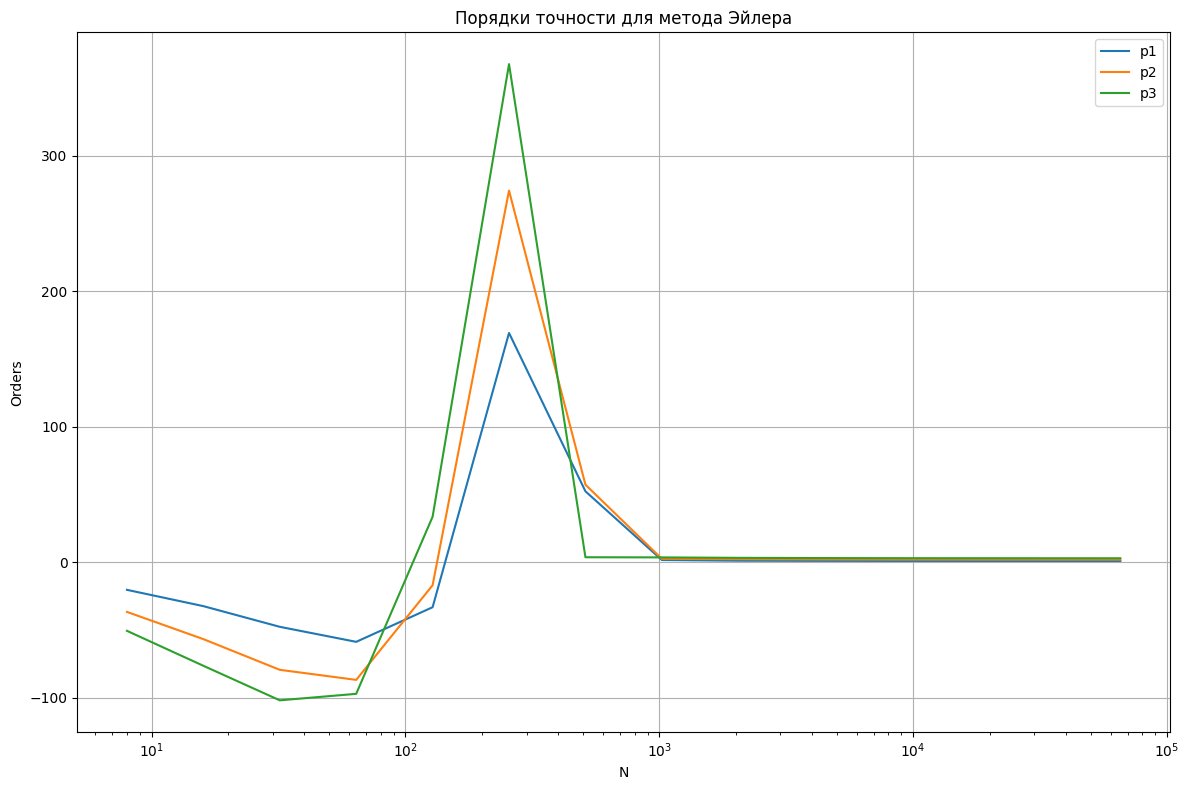

In [15]:
"""
Построим график изменения порядка
"""

plt.figure(figsize=(12,8))
plt.semilogx(N, p1, label="p1")
plt.semilogx(N, p2, label="p2")
plt.semilogx(N, p3, label="p3")
plt.title("Порядки точности для метода Эйлера")
plt.xlabel("N")
plt.ylabel("Orders")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

Решим теперь ту же самую задачу, но с помощью **неявного метода Эйлера**.

### Неявный метод Эйлера.

В неявном методе Эйлера мы используем значение $y_{i+1}$, которое стоит по обе стороны уравнения, поэтому метод и **неявный**.   
$$y_{i+1} = y_i + hf(t_{i+1}, y_{i+1})$$
Наше уравнение: $y' = \lambda y$:  
$$f(t,y) = \lambda y \Longrightarrow y_{i+1} = y_i + h \lambda y_{i+1} \Longrightarrow$$
$$\Longrightarrow y_{i+1}(1-h \lambda) = y_i \Longrightarrow y_{i+1} = \frac{y_i}{1 - h \lambda}$$

In [16]:
def implicit_method(t, y, h, f):
    return y / (1 - h * Lambda)

In [17]:
errors_imp = []

for n in N:
    domain, h = grid(a, b, n)

    values_imp = [y0]
    values_analytic = [analytic_solution(y0, Lambda, domain[0], domain[0])]

    for t in range(1, len(domain)):
        values_imp.append(implicit_method(domain[t-1], values_imp[t-1], h, f))
        values_analytic.append(analytic_solution(y0, Lambda, domain[0], domain[t]))

    errors_imp.append(inaccuracy(values_imp, values_analytic))

p_imp = [np.nan] + [np.log2(errors_imp[i-1] / errors_imp[i]) for i in range(1, len(errors_imp))]

df_imp = pd.DataFrame({
    "N": N,
    "h": H,
    "eps_imp": errors_imp,
    "p_imp": p_imp
})

display(df_imp)

,N,h,eps_imp,p_imp
0,4,27.500000,0.108303,NaN
1,8,13.750000,0.215054,-0.989621
2,16,6.875000,0.424028,-0.979463
3,32,3.437500,0.824742,-0.959782
4,64,1.718750,1.560739,-0.920215
5,128,0.859375,2.627693,-0.751567
6,256,0.429688,3.014273,-0.198014
7,512,0.214844,2.108171,0.515818
8,1024,0.107422,1.225187,0.782989
9,2048,0.053711,0.668878,0.873187


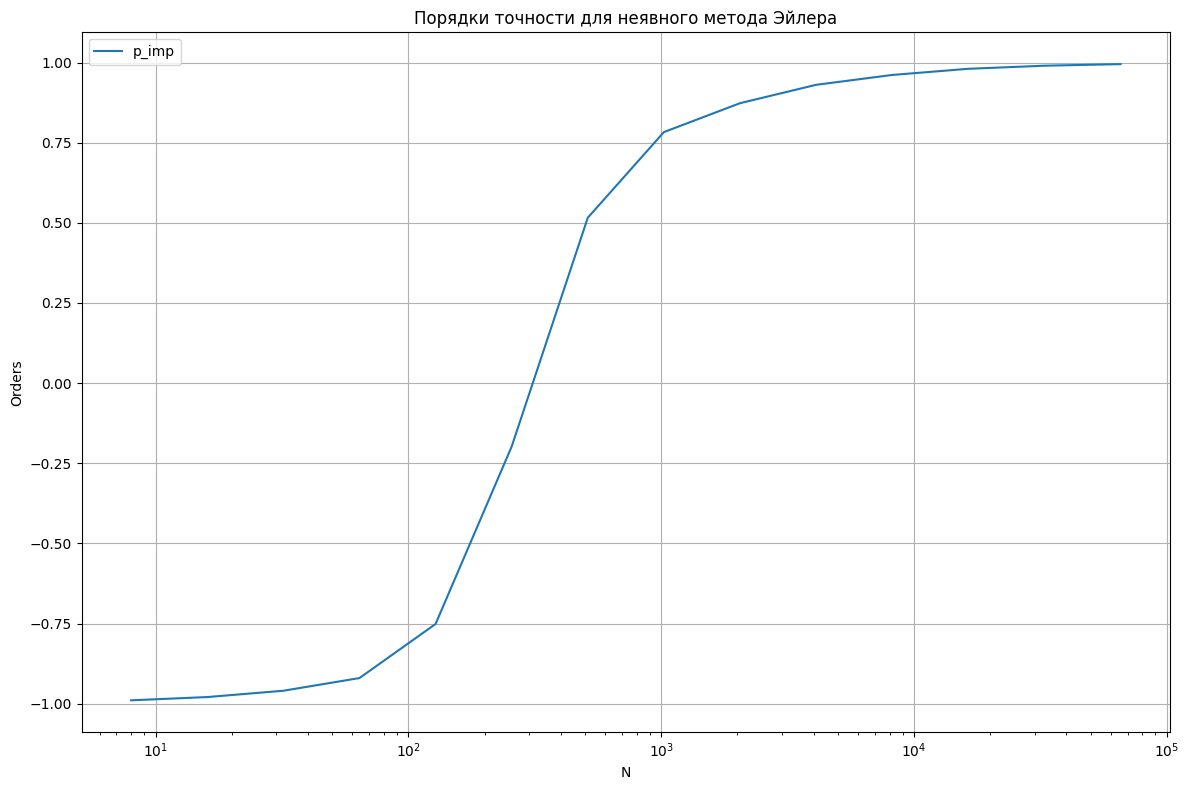

In [18]:
"""
Построим график изменения порядка
"""

plt.figure(figsize=(12,8))
plt.semilogx(N, p_imp, label="p_imp")
plt.title("Порядки точности для неявного метода Эйлера")
plt.xlabel("N")
plt.ylabel("Orders")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

Локальная погрешность метода = 2 $\Longrightarrow$ глобальная = 1. Вычисления соответствуют теории.

### Модифицированный метод Эйлера (метод предиктора-корректора)  

Метод реализуется с помощью системы, состоящей из **предиктора** и **корректора**.  

**Предиктор**: $$ \widetilde{y_{i+1}} = y_i + hf(x_i, y_i)$$  
Предиктор дает предварительное приближение в точке с помощью обычного метода Эйлера. 

**Корректор**: $$y_{i+1} = y_i + \frac{h}{2}(f(x_i, y_i) + f(x_i + h, \widetilde{y_{i+1}}))$$
Корректор уточняет шаг, усредняя наклон: в начале и в конце шага.  

Подставляем предиктор в корректор и получаем одношаговую формулу: $$y_{i+1} = y_i + \frac{h}{2}(f(x_i, y_i) + f(x_i + h, y_i + hf(x_i, y_i)))$$

In [19]:
def modified_euler(t, y, h, f):
    y_pred = y + h * f(t,y)
    
    y_next = y + h / 2 * (f(t, y) + f(t + h, y_pred))

    return y_next

In [20]:
errors_mod = []

for n in N:
    domain, h = grid(a, b, n)

    values_mod = [y0]
    values_analytic = [analytic_solution(y0, Lambda, domain[0], domain[0])]

    for t in range(1, len(domain)):
        values_mod.append(modified_euler(domain[t-1], values_mod[t-1], h, f))
        values_analytic.append(analytic_solution(y0, Lambda, domain[0], domain[t]))

    errors_mod.append(inaccuracy(values_analytic, values_mod))

p_mod = [np.nan] + [np.log2(errors_mod[i-1] / errors_mod[i]) for i in range(1, len(errors_mod))]

df_mod = pd.DataFrame({
    "N": N,
    "h": H,
    "eps_mod": errors_mod,
    "p_mod": p_mod
})

display(df_mod)

,N,h,eps_mod,p_mod
0,4,27.500000,1.130123e+17,NaN
1,8,13.750000,1.156530e+28,-36.574532
2,16,6.875000,1.304150e+45,-56.646085
3,32,3.437500,9.628817e+68,-79.288595
4,64,1.718750,1.220256e+95,-86.711883
5,128,0.859375,1.482731e+100,-16.890714
6,256,0.429688,4.217221e+17,274.211997
7,512,0.214844,2.417846e+00,57.275348
8,1024,0.107422,4.057055e-01,2.575217
9,2048,0.053711,8.150759e-02,2.315426


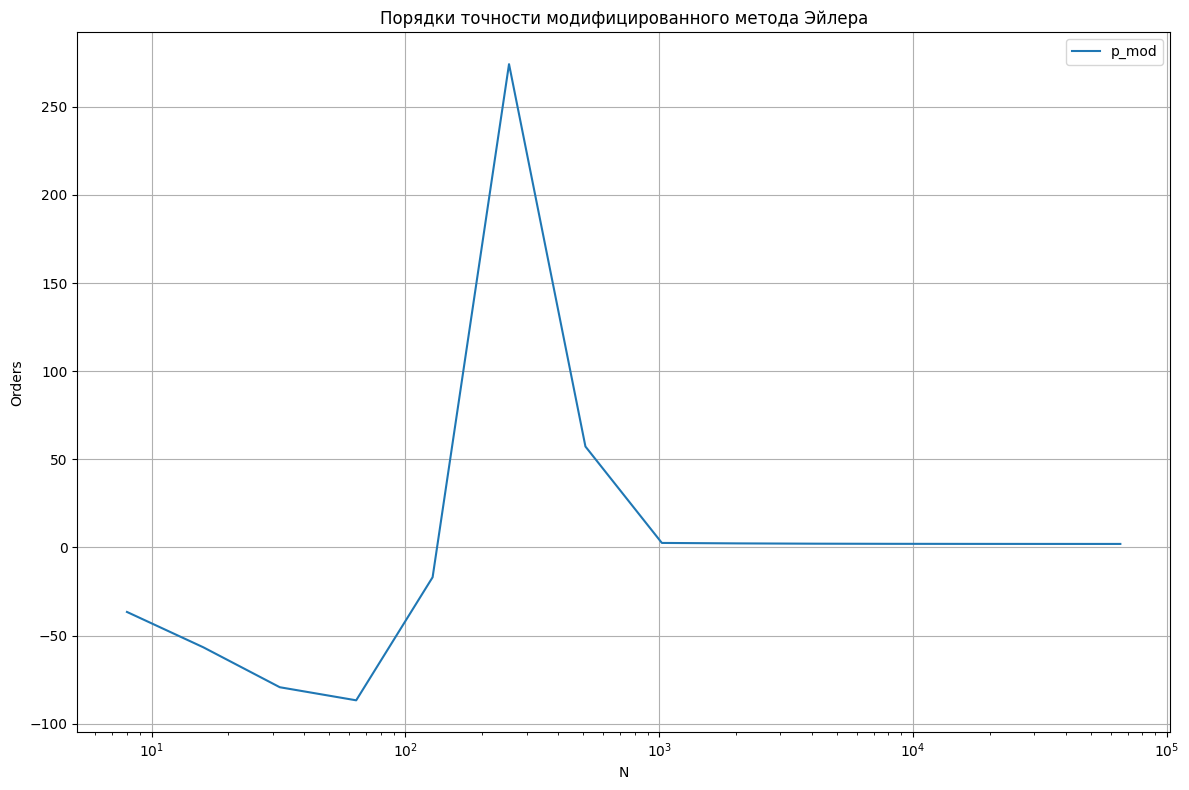

In [21]:
"""
Построим график изменения порядка
"""

plt.figure(figsize=(12,8))
plt.semilogx(N, p_mod, label="p_mod")
plt.title("Порядки точности модифицированного метода Эйлера")
plt.xlabel("N")
plt.ylabel("Orders")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

локальная погрешность метода = 3 $\Longrightarrow$ глобальная = 2

### 4 метод (метод центральных разностей).  
$$f(y_n) = \frac{y_{n+1} - y_{n-1}}{2h}$$
Для уравнения $y' = f(t,y)$ подставляем вместо $y'$: $f(t_n, y_n) = \frac{y_{n+1} - y_{n-1}}{2h}$, получаем:  
$$y_{n+1} = y_{n-1} + 2hf(t_n, y_n)$$

In [22]:
def central_difference_method(t, y_prev, y_current, h, f):
    return y_prev + 2*h*f(t, y_current)

In [23]:
errors_cd = []

for n in N:
    domain, h = grid(a, b, n)
    
    values_cd = [y0]

    values_cd.append(values_cd[0] + h * f(domain[0], values_cd[0]))

    values_analytic = [
        analytic_solution(y0, Lambda, domain[0], domain[0]),
        analytic_solution(y0, Lambda, domain[0], domain[1])
    ]

    for t in range(1, len(domain)-1):
        values_cd.append(
            central_difference_method(domain[t], values_cd[t-1], values_cd[t], h, f)
        )
        values_analytic.append(
            analytic_solution(y0, Lambda, domain[0], domain[t+1])
        )

    errors_cd.append(inaccuracy(values_analytic, values_cd))

p_cd = [np.nan] + [np.log2(errors_cd[i-1] / errors_cd[i]) for i in range(1, len(errors_cd))]

df_cd = pd.DataFrame({
    "N": N,
    "h": H,
    "eps_cd": errors_cd,
    "p_cd": p_cd
})

display(df_cd)

,N,h,eps_cd,p_cd
0,4,27.500000,4.258386e+10,NaN
1,8,13.750000,9.447217e+17,-24.403079
2,16,6.875000,1.820029e+30,-40.809137
3,32,3.437500,1.048544e+50,-65.642987
4,64,1.718750,9.309928e+79,-99.486298
5,128,0.859375,1.193114e+121,-136.556942
6,256,0.429688,2.033322e+168,-156.899727
7,512,0.214844,6.534904e+207,-131.239523
8,1024,0.107422,4.021547e+228,-69.060075
9,2048,0.053711,3.086720e+235,-22.871821


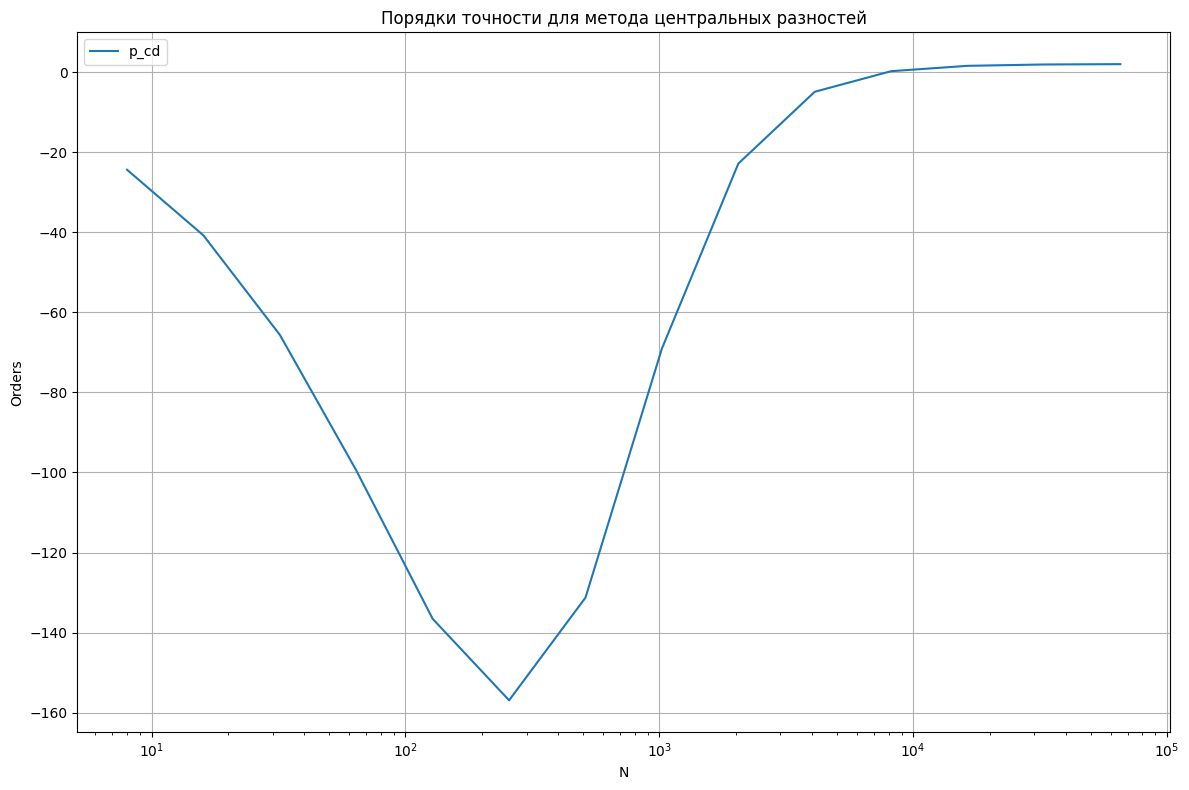

In [24]:
"""
Построим график изменения порядка
"""

plt.figure(figsize=(12,8))
plt.semilogx(N, p_cd, label="p_cd")
plt.title("Порядки точности для метода центральных разностей")
plt.xlabel("N")
plt.ylabel("Orders")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

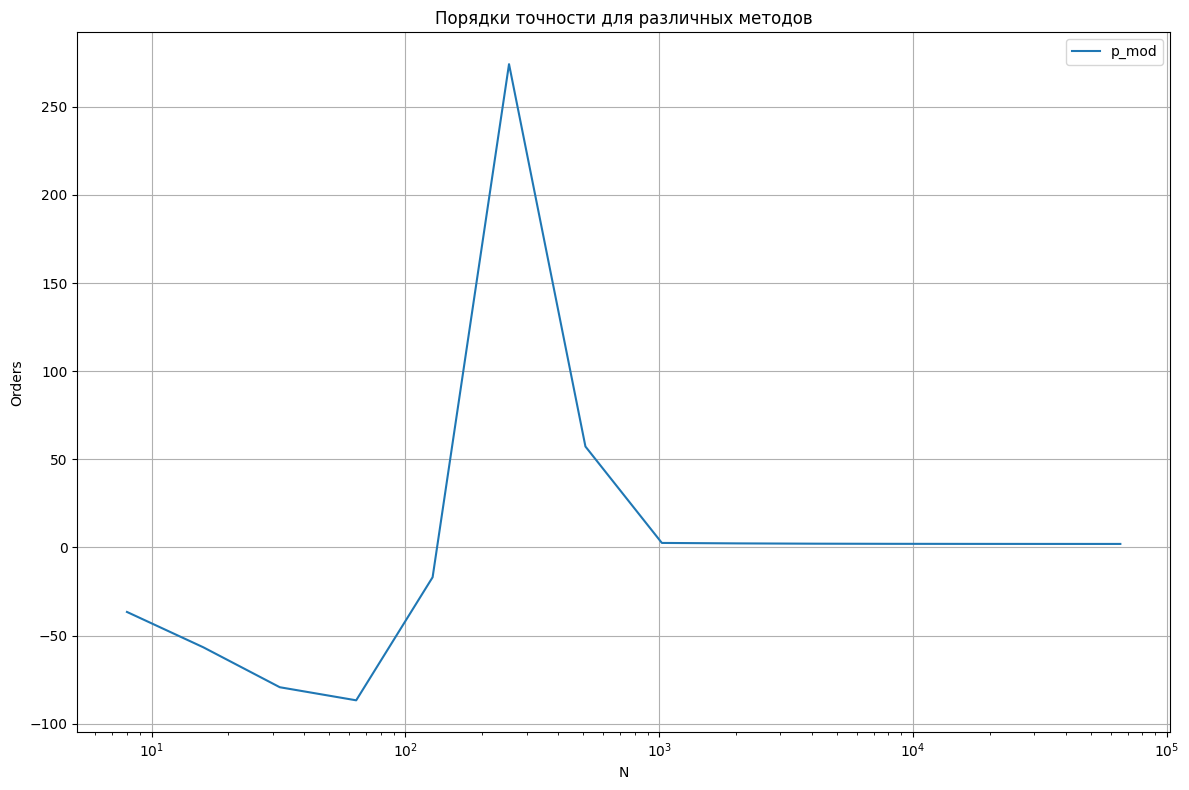

In [25]:
"""
Построим график изменения порядков всех методов
"""

plt.figure(figsize=(12,8))
#plt.semilogx(N, p_cd, label="p_cd")
plt.semilogx(N, p_mod, label="p_mod")
#plt.semilogx(N, p_imp, label="p_imp")
#plt.semilogx(N, p1, label="p1")
#plt.semilogx(N, p2, label="p2")
#plt.semilogx(N, p3, label="p3")
plt.title("Порядки точности для различных методов")
plt.xlabel("N")
plt.ylabel("Orders")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [26]:
def build_error_table(methods, N, a, b, y0, f, Lambda):
    def one_step_error(method, n):
        domain, h = grid(a, b, n)

        values = [y0]
        values_analytic = [analytic_solution(y0, Lambda, domain[0], domain[0])]

        for t in range(1, len(domain)):
            values.append(method(domain[t-1], values[t-1], h, f))
            values_analytic.append(
                analytic_solution(y0, Lambda, domain[0], domain[t])
            )

        err = inaccuracy(values_analytic, values)
        return h, err

    def two_step_error(method, n):
        domain, h = grid(a, b, n)

        values = [y0]
        values.append(y0 + h * f(domain[0], y0))  

        values_analytic = [
            analytic_solution(y0, Lambda, domain[0], domain[0]),
            analytic_solution(y0, Lambda, domain[0], domain[1])
        ]

        for t in range(1, len(domain) - 1):
            values.append(method(domain[t], values[t-1], values[t], h, f))
            values_analytic.append(
                analytic_solution(y0, Lambda, domain[0], domain[t+1])
            )

        err = inaccuracy(values_analytic, values)
        return h, err

    data = {
        "N": N,
        "h": []
    }

    for method_name, method_info in methods.items():
        method_func = method_info["func"]
        method_type = method_info["type"]

        errors = []
        hs = []

        for n in N:
            if method_type == "one-step":
                h, err = one_step_error(method_func, n)
            elif method_type == "two-step":
                h, err = two_step_error(method_func, n)
            else:
                raise ValueError(f"Unknown method type: {method_type}")

            hs.append(h)
            errors.append(err)

        orders = [np.nan]

        for i in range(1, len(errors)):
            e_prev = errors[i-1]
            e_curr = errors[i]

            if e_prev == 0 or e_curr == 0 or not np.isfinite(e_prev) or not np.isfinite(e_curr):
                orders.append(np.nan)
            else:
                orders.append(np.log2(e_prev / e_curr))

        if len(data["h"]) == 0:
            data["h"] = hs

        data[f"eps_{method_name}"] = errors
        data[f"p_{method_name}"] = orders

    return pd.DataFrame(data)

In [27]:
methods = {
    "ps1": {"func": power_series_method_1, "type": "one-step"},
    "ps2": {"func": power_series_method_2, "type": "one-step"},
    "ps3": {"func": power_series_method_3, "type": "one-step"},
    "imp": {"func": implicit_method, "type": "one-step"},
    "mod": {"func": modified_euler, "type": "one-step"},
    "cd": {"func": central_difference_method, "type": "two-step"},
}

df_all = build_error_table(methods, N, a, b, y0, f, Lambda)
display(df_all)

,N,h,eps_ps1,p_ps1,eps_ps2,p_ps2,eps_ps3,p_ps3,eps_imp,p_imp,eps_mod,p_mod,eps_cd,p_cd
0,4,27.500000,5.207411e+09,NaN,1.130123e+17,NaN,4.845699e+23,NaN,0.108303,NaN,1.130123e+17,NaN,4.258386e+10,NaN
1,8,13.750000,6.658335e+15,-20.286164,1.156530e+28,-36.574532,7.851491e+38,-50.525184,0.215054,-0.989621,1.156530e+28,-36.574532,9.447217e+17,-24.403079
2,16,6.875000,3.554935e+25,-32.313943,1.304150e+45,-56.646085,7.382597e+61,-76.315508,0.424028,-0.979463,1.304150e+45,-56.646085,1.820029e+30,-40.809137
3,32,3.437500,7.410445e+39,-47.566730,9.628817e+68,-79.288595,3.222817e+92,-101.783965,0.824742,-0.959782,9.628817e+68,-79.288595,1.048544e+50,-65.642987
4,64,1.718750,3.351924e+57,-58.650135,1.220256e+95,-86.711883,5.137410e+121,-97.008633,1.560739,-0.920215,1.220256e+95,-86.711883,9.309928e+79,-99.486298
5,128,0.859375,3.113213e+67,-33.112696,1.482731e+100,-16.890714,3.863191e+111,33.630529,2.627693,-0.751567,1.482731e+100,-16.890714,1.193114e+121,-136.556942
6,256,0.429688,3.660806e+16,169.184576,4.217221e+17,274.211997,9.149986e+00,367.490042,3.014273,-0.198014,4.217221e+17,274.211997,2.033322e+168,-156.899727
7,512,0.214844,6.236749e+00,52.382217,2.417846e+00,57.275348,6.811302e-01,3.747767,2.108171,0.515818,2.417846e+00,57.275348,6.534904e+207,-131.239523
8,1024,0.107422,1.909452e+00,1.707636,4.057055e-01,2.575217,5.466401e-02,3.639267,1.225187,0.782989,4.057055e-01,2.575217,4.021547e+228,-69.060075
9,2048,0.053711,8.318840e-01,1.198704,8.150759e-02,2.315426,5.509158e-03,3.310688,0.668878,0.873187,8.150759e-02,2.315426,3.086720e+235,-22.871821


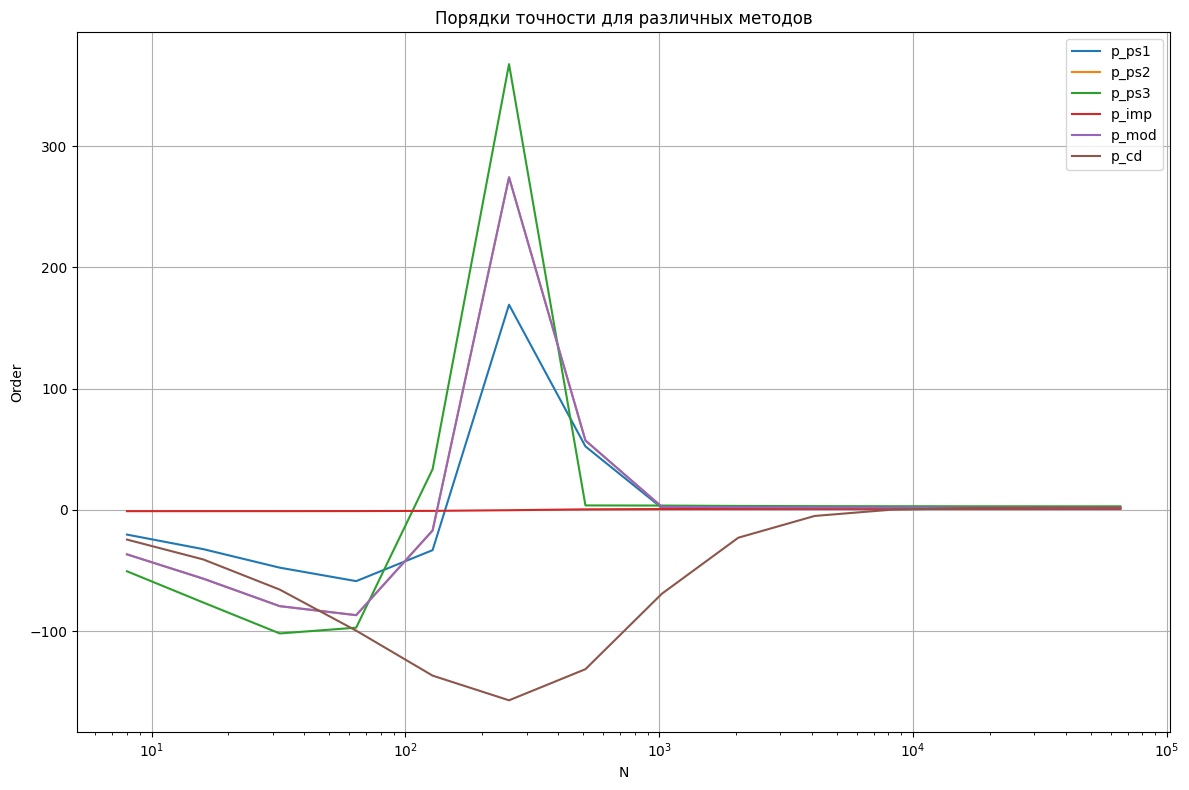

In [28]:
plt.figure(figsize=(12,8))

for col in df_all.columns:
    if col.startswith("p_"):
        plt.semilogx(df_all["N"], df_all[col], label=col)

plt.title("Порядки точности для различных методов")
plt.xlabel("N")
plt.ylabel("Order")

plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

### Часть 2: разные $\lambda$

In [29]:
lambdas = [-i for i in range(1, 16)]

Lambda = -1



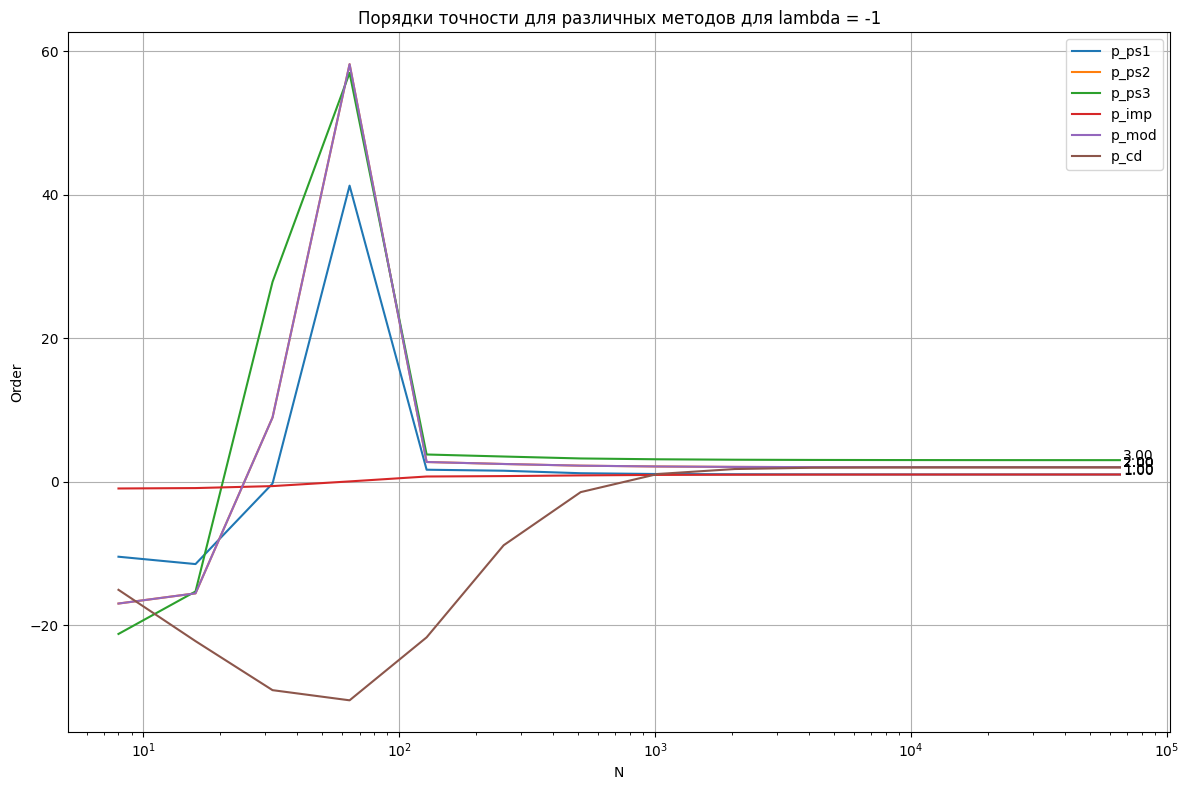

Lambda = -2



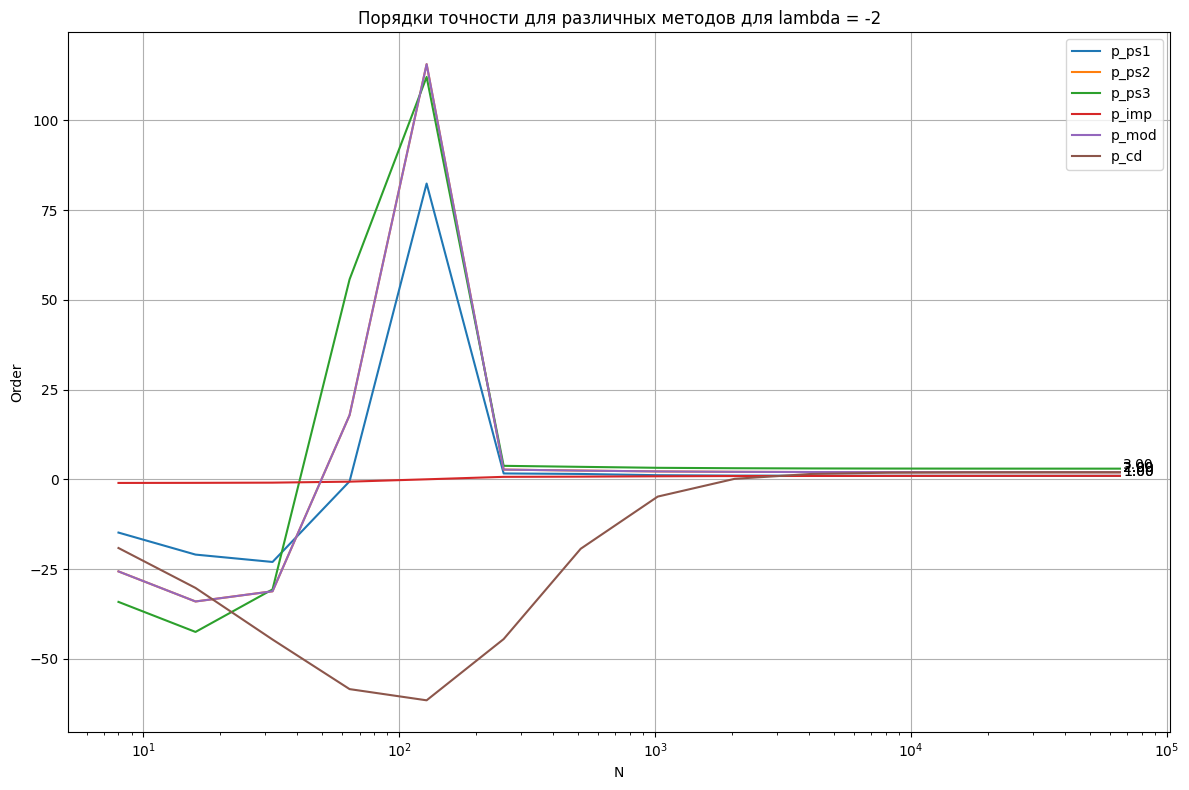

Lambda = -3



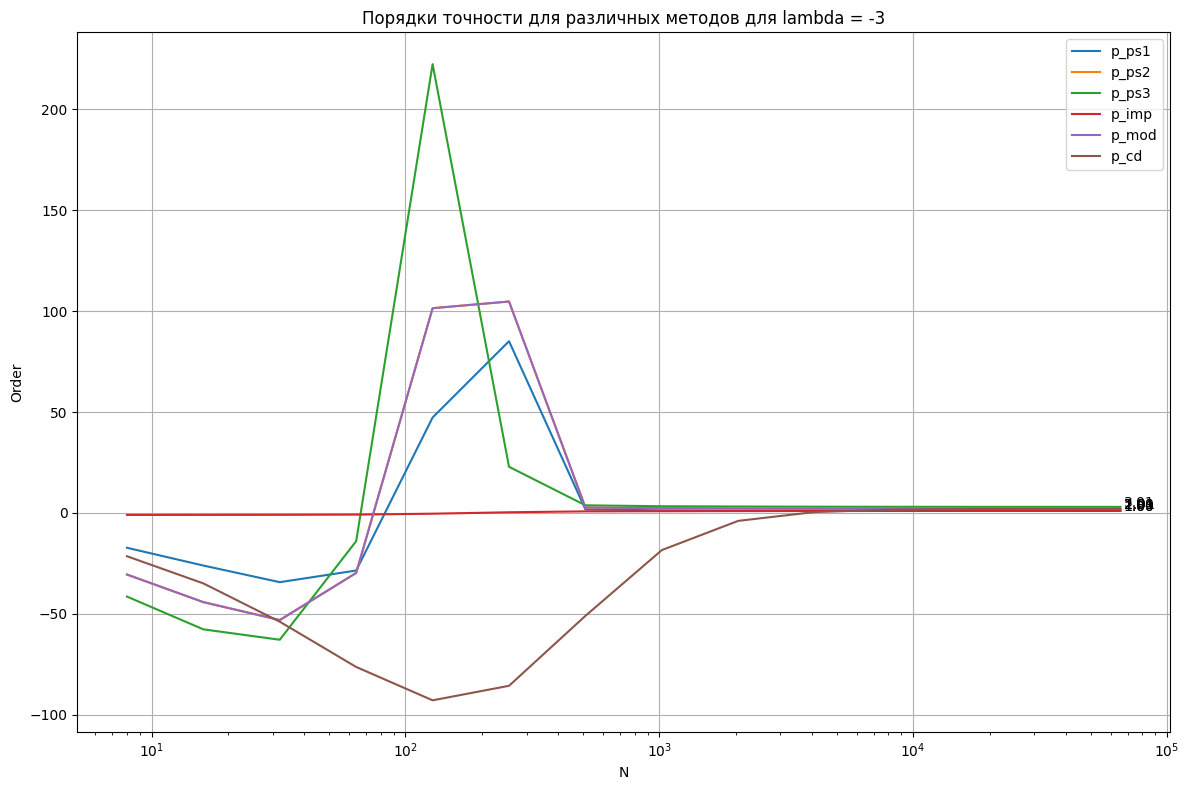

Lambda = -4



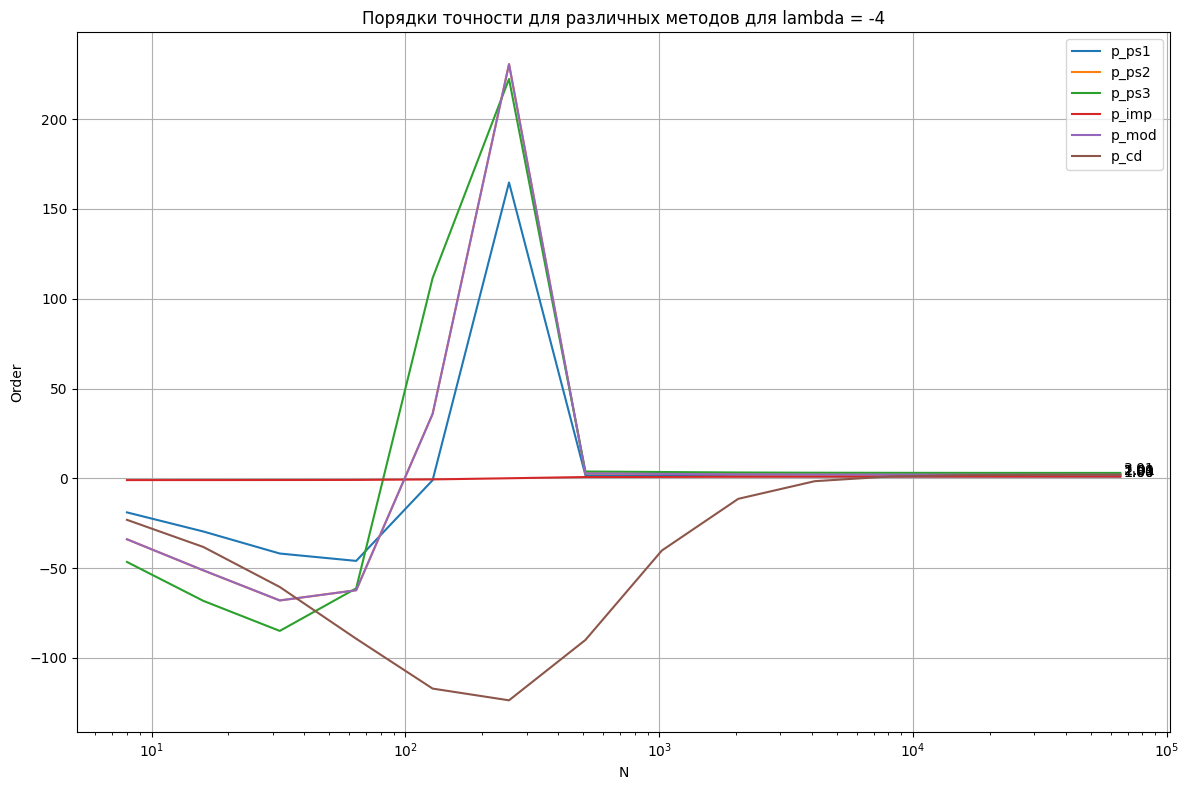

Lambda = -5



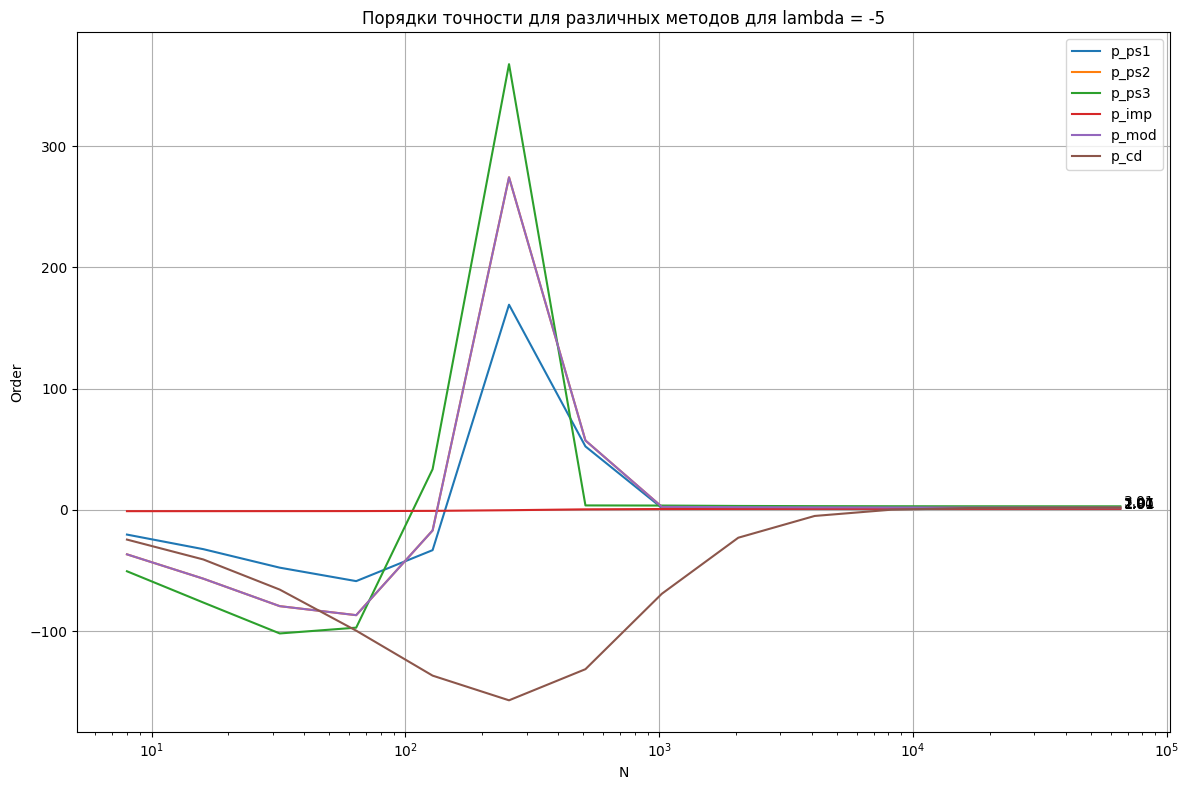

Lambda = -6



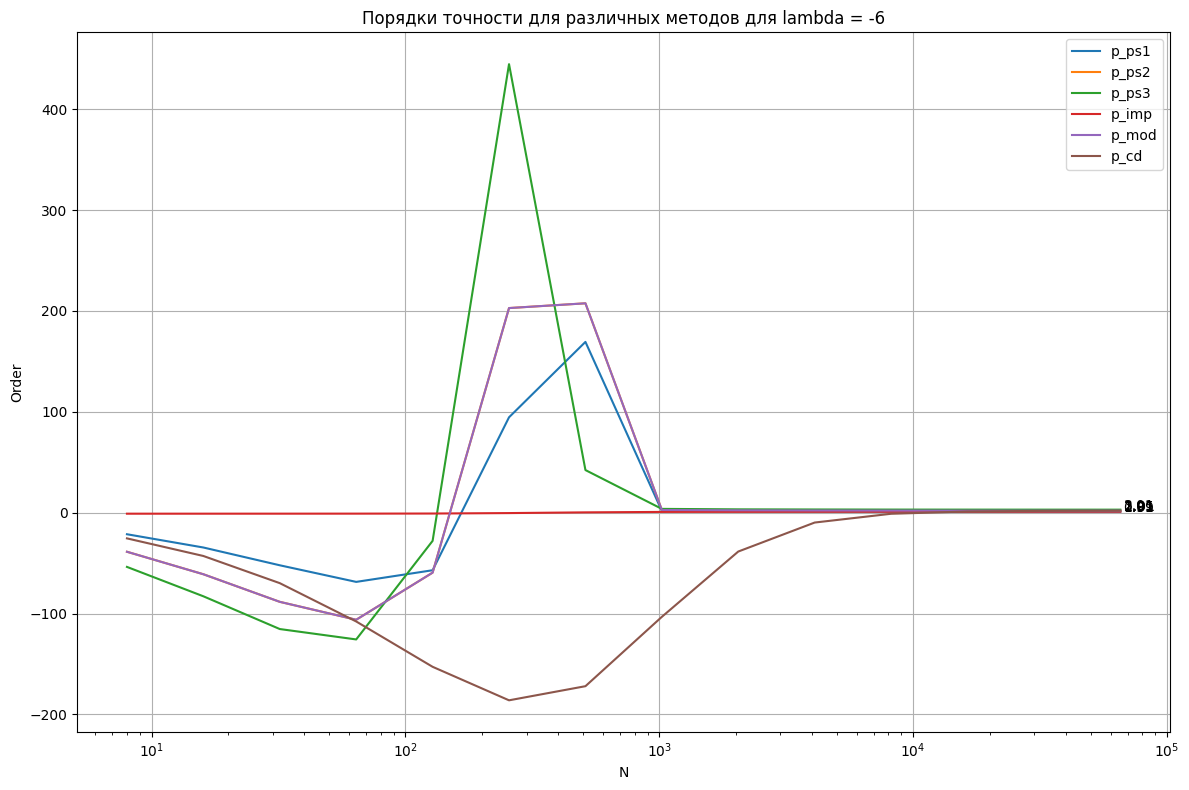

Lambda = -7



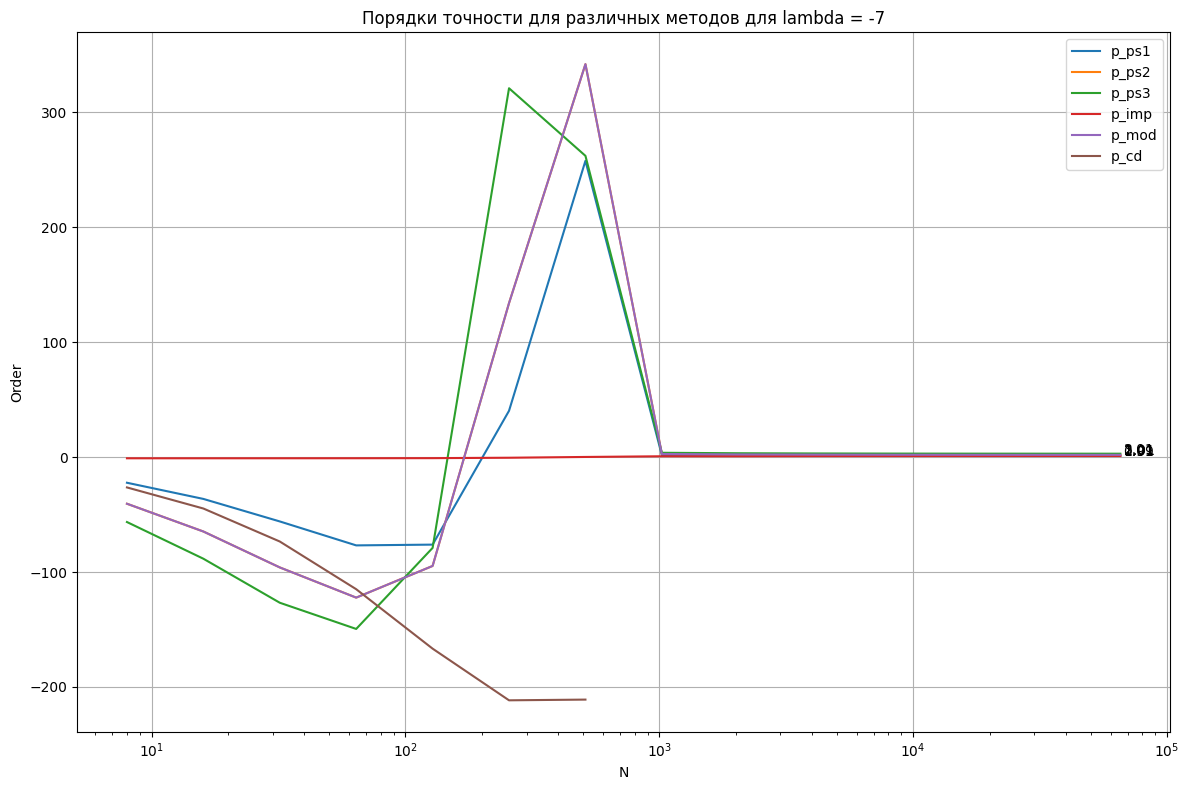

Lambda = -8



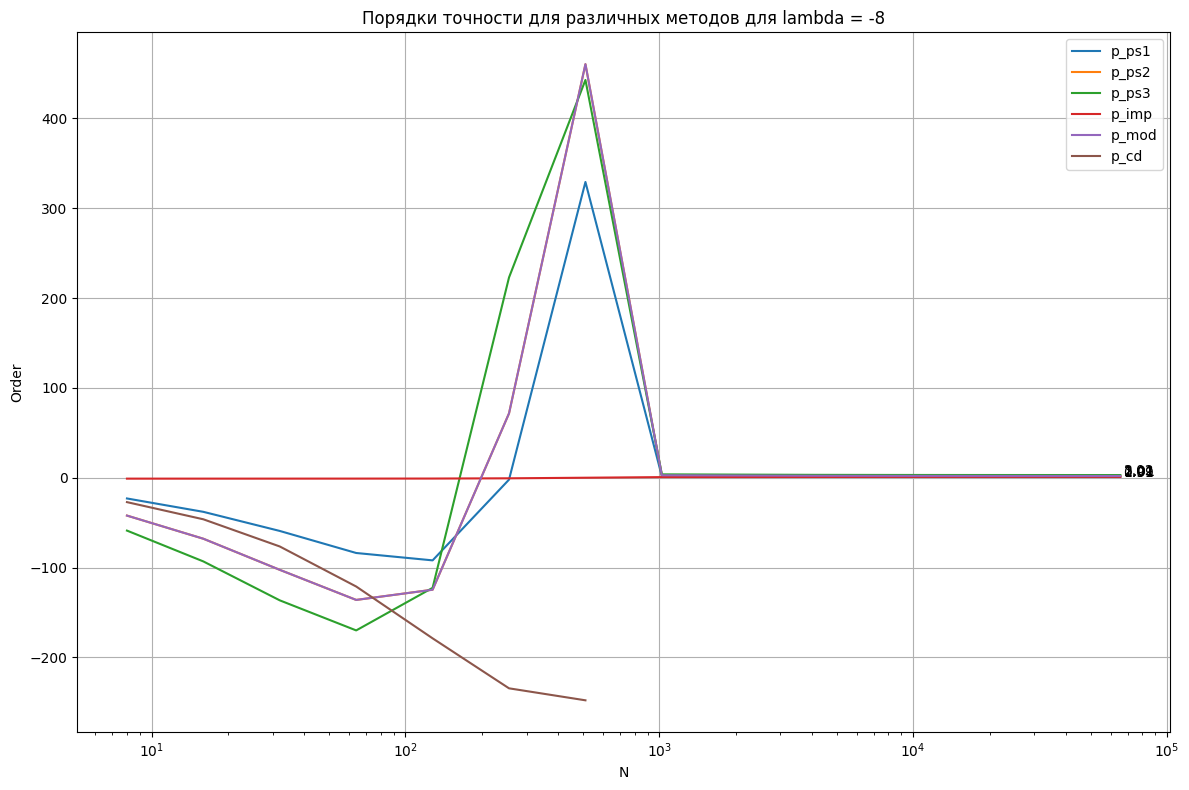

Lambda = -9



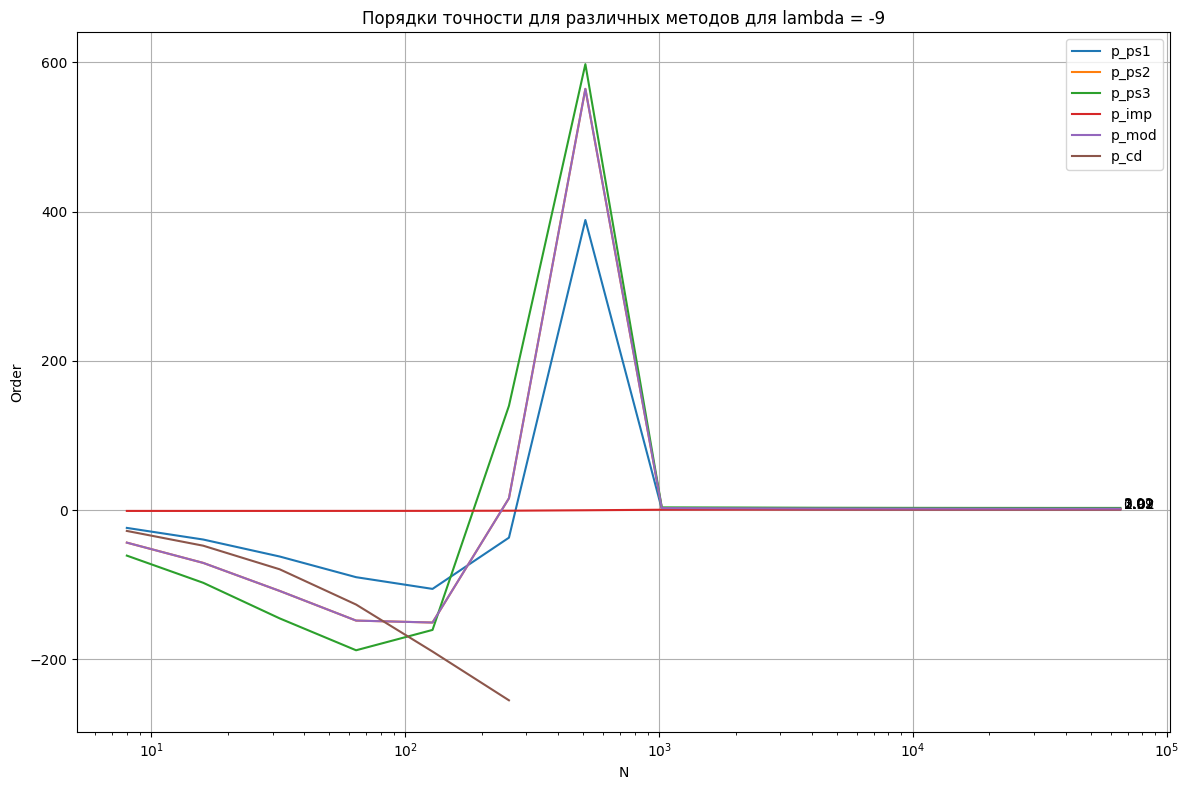

Lambda = -10



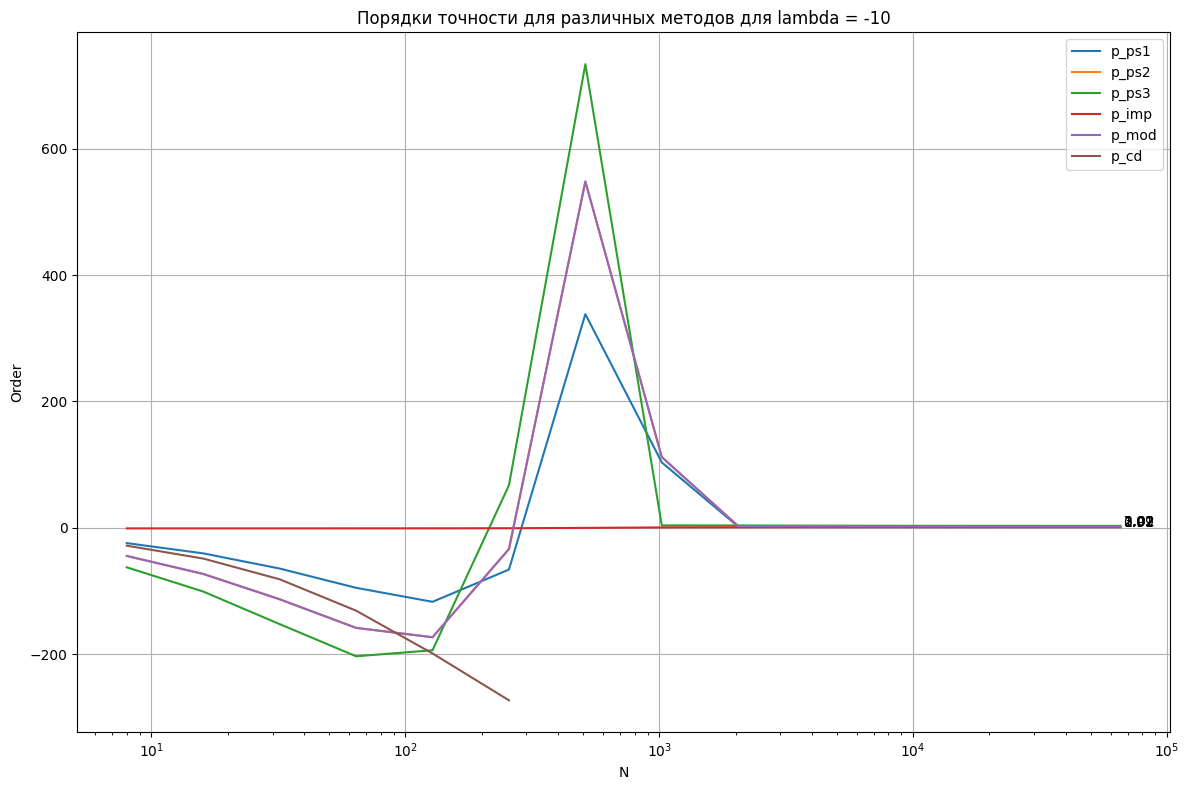

Lambda = -11



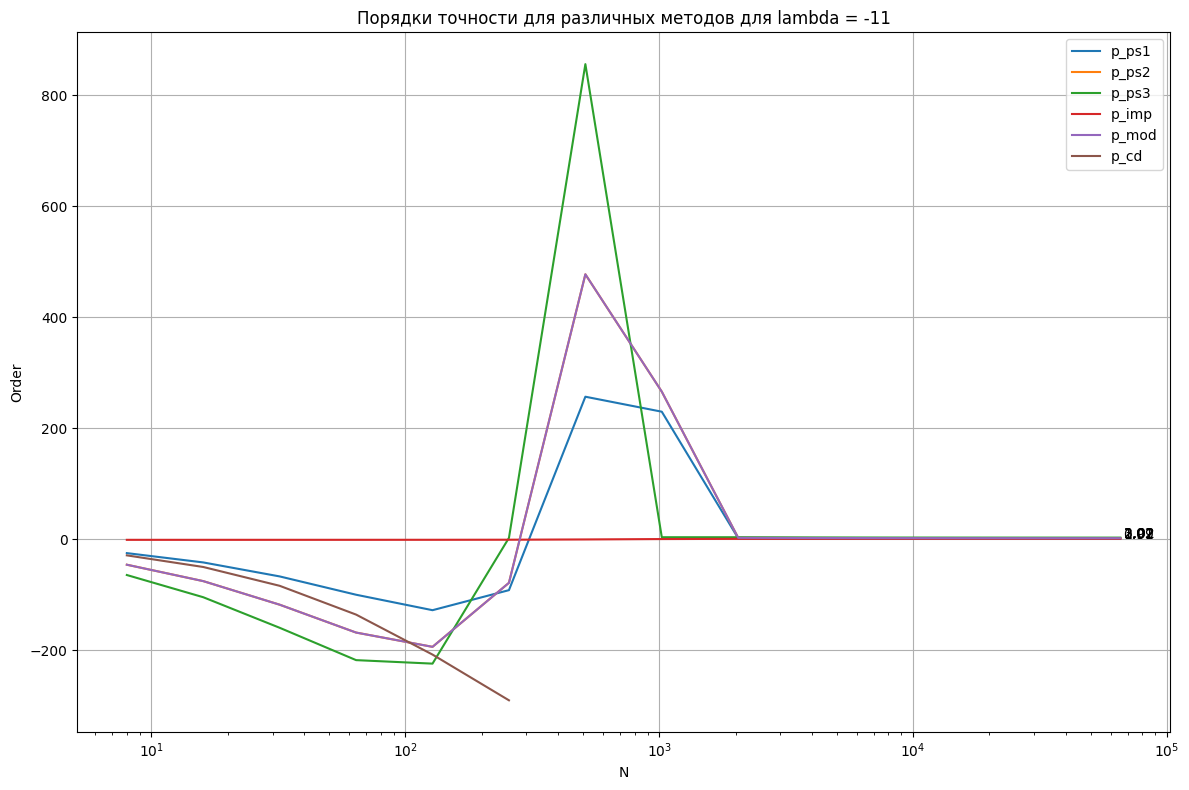

Lambda = -12



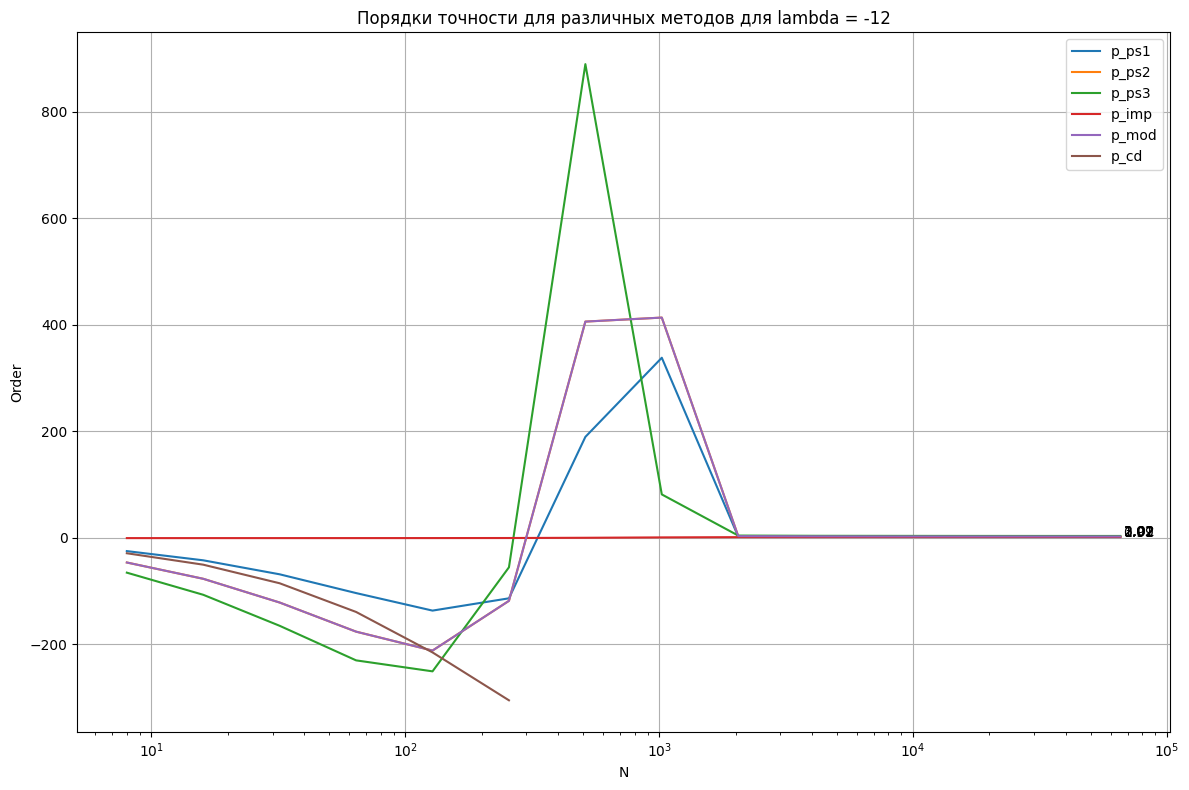

Lambda = -13



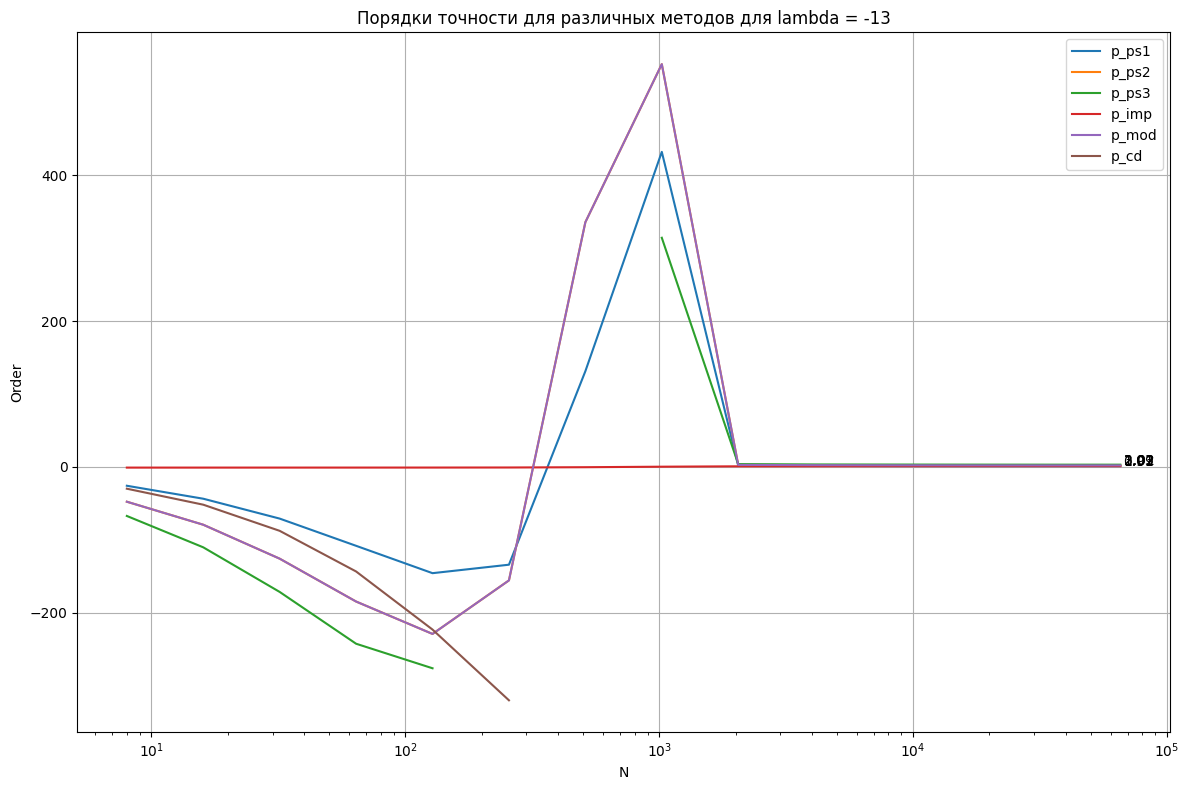

Lambda = -14



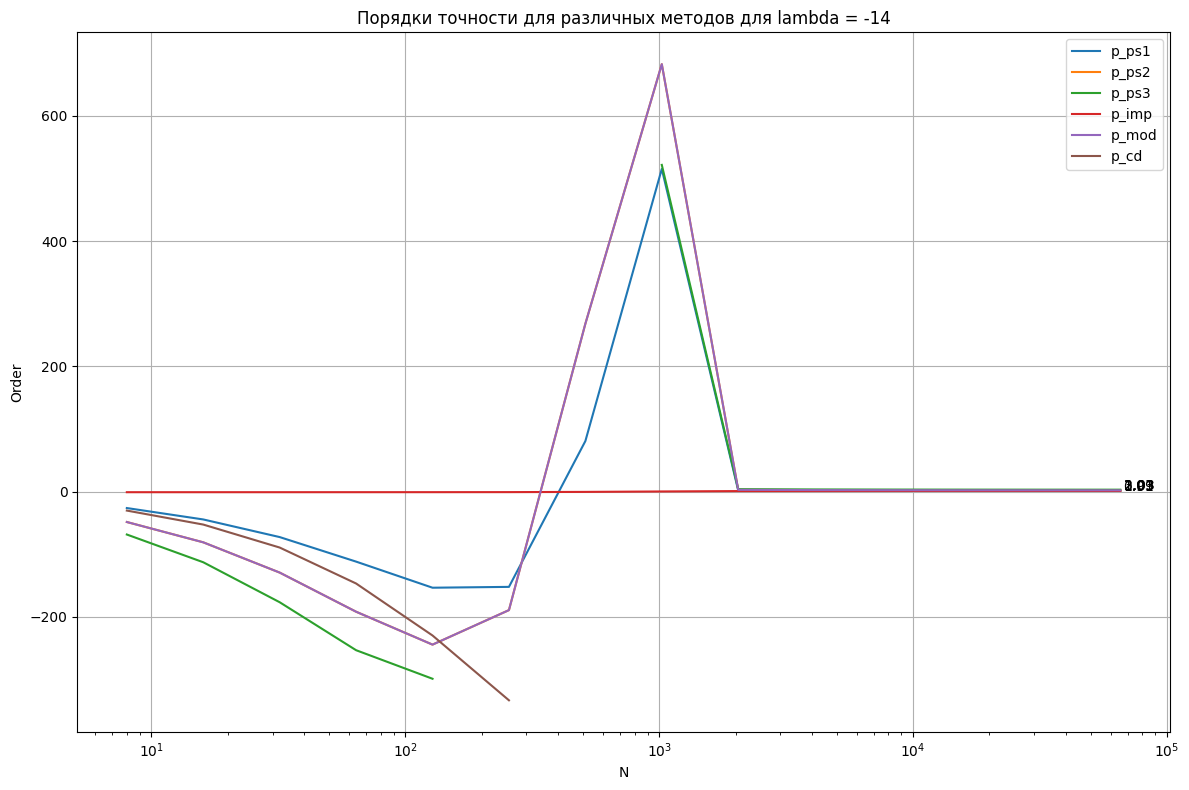

Lambda = -15



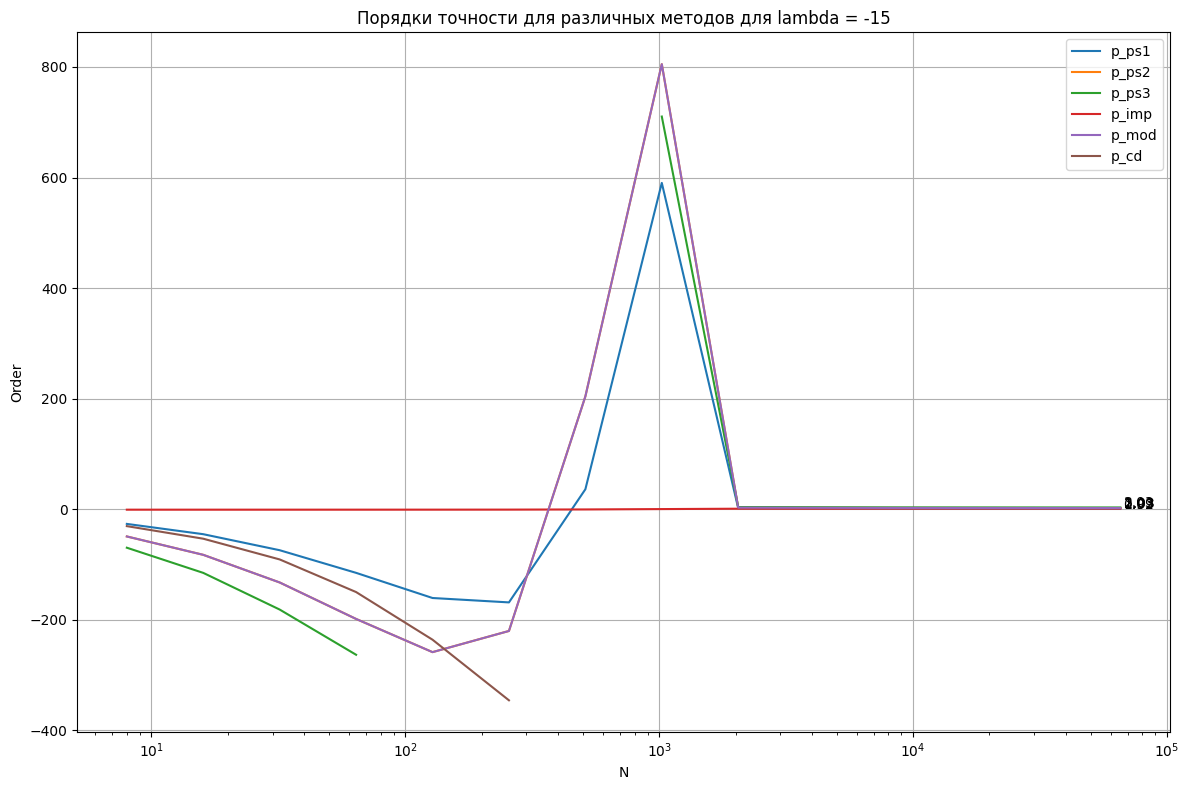

In [30]:
for l in lambdas:
    Lambda = l
    f = lambda t, y: Lambda * y
    df_all = build_error_table(methods, N, a, b, y0, f, Lambda)
    print(f"Lambda = {l}\n")

    plt.figure(figsize=(12,8))

    for col in df_all.columns:
        if col.startswith("p_"):
            plt.semilogx(df_all["N"], df_all[col], label=col)

            x = df_all["N"].iloc[-1]
            y = df_all[col].iloc[-1]

            if np.isfinite(y):
                plt.text(x * 1.03, y, f"{y:.2f}")

    plt.title(f"Порядки точности для различных методов для lambda = {l}")
    plt.xlabel("N")
    plt.ylabel("Order")

    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

### Вторая часть лабораторной работы

Необходимо решить аналогичную задачу: 
1) используя методы Адамса - Б, Адамса - М, Адамса - Б - М.
2) Метод Гира.
3) Решить задачу: 
$$
\begin{cases}
\frac{dy_1}{dt} = f_1 \\
\frac{dy_2}{dt} = f_2
\end{cases}
$$
4) Оценить погрешность: сравнить с точным методом, с методом Рунге, сравнить с эталоном на очень маленькой сетке.


### Многошаговые методы Адамса

Рассматривемый нами метод является **многошаговым**, то есть его рассчечтная формула может быть записана в виде: $$y_{j+1} = Y(x_j, x_{j-1}, ... , x_{j-M}, y_{j}, y_{j-1}, ... , y_{j-m})$$

И в частности для **явных** многошаговых методов: $$y_{j+1} = Y(x_{j+1}, x_{j}, ... , x_{j-M}, y_{j+1}, y_{j}, ... , y_{j-m})$$

Как получаем метод? Находим решение ОДУ, разрешенного относительно производой на отрезке $[x_j, x_{j+1}]$: $$y' = f(x,y) \xrightarrow{\int} y(x_{j+1}) = y(x_j) + \int_{x_j}^{x_{j+1}}f(x,y(x))dx$$

Положим $f(x,y) = F(x)$ и заменим эту подынтегральную функциую полиномом **Лагранжа**, постренном по узлам $x_j, x_{j-1}, x_{j-2},...,x_{j-M}$ для явных методов и по узлам $x_{j+1}, x_{j}, x_{j-1},...,x_{j-M}$ для неявных.  

Получаем $$F(x) \approx L_M(x), L_M(x_k) = F(x_k) = f_k = f(x_k, y_k) \Longrightarrow$$
$$\Longrightarrow y_{j+1} = y_j + \int_{x_j}^{x_{j+1}}L_M(x)dx \ \ (1)$$

Это общая формула многошаговых методов Адамса.



### Явный двухшаговый метод Адамса (Метод Адамса - Башфорта)

$$L_M(x) = \sum_{k=j}^{j-M}f_k \frac{(x-x_j)...(x-x_{k+1})(x-x_{k-1})...(x-x_j-M)}{(x_k-x_j)...(x_k-x_{k+1})(x_k-x_{k-1})...(x_k-x_{j-M})} \Longrightarrow$$
$$\Longrightarrow L_1(x) = f_j \frac{x - x_{j-1}}{x_j - x_{j-1}} + f_{j-1}\frac{x-x_j}{x_{j-1} - x_j} = \frac{1}{h} [(x-x_{j-1}f_j - (x-x_j)f_{j-1})]$$

Подставим это в $(1)$ и получим: $$y_{j+1} = y_j + \frac{1}{h} \int_{x_j}^{x_{j+1}} [(x-x_{j-1}f_j - (x-x_j)f_{j-1})]dx = ... = y_j + \frac{h}{2}(3f_j - f_{j-1})$$

Таким образом: $$y_{j+1} = y_j + \frac{h}{2}(3f_j - f_{j-1})$$

In [31]:
def adams_explicit_2(t_j, y_j, y_jm1, h, f):
    f_j = f(t_j, y_j)
    f_jm1 = f(t_j - h, y_jm1)

    return y_j + h/2 * (3 * f_j - f_jm1)

In [32]:
errors_adams_exp_2 = []

for n in N:
    domain, h = grid(a, b, n)

    values_adams_exp_2 = [y0]

    y1 = power_series_method_2(domain[0], values_adams_exp_2[0], h, f)
    values_adams_exp_2.append(y1)

    values_analytic = [
        analytic_solution(y0, Lambda, domain[0], domain[0]),
        analytic_solution(y0, Lambda, domain[0], domain[1])
    ]

    for j in range(1, len(domain) - 1):
        y_next = adams_explicit_2(
            domain[j],
            values_adams_exp_2[j],
            values_adams_exp_2[j - 1],
            h,
            f
        )
        values_adams_exp_2.append(y_next)

        values_analytic.append(
            analytic_solution(y0, Lambda, domain[0], domain[j + 1])
        )

    errors_adams_exp_2.append(inaccuracy(values_analytic, values_adams_exp_2))

In [33]:
p_adams_exp_2 = [np.nan]

for i in range(1, len(errors_adams_exp_2)):
    p_adams_exp_2.append(np.log2(errors_adams_exp_2[i - 1] / errors_adams_exp_2[i]))

C:\Users\Cyber Kanojo\AppData\Local\Temp\ipykernel_7160\2212674529.py:4: RuntimeWarning: divide by zero encountered in log2
  p_adams_exp_2.append(np.log2(errors_adams_exp_2[i - 1] / errors_adams_exp_2[i]))


In [34]:
df_adams_exp_2 = pd.DataFrame({
    "N": N,
    "eps_adams_exp_2": errors_adams_exp_2,
    "p_adams_exp_2": p_adams_exp_2
})

df_adams_exp_2

,N,eps_adams_exp_2,p_adams_exp_2
0,4,2.997155e+14,NaN
1,8,8.433481e+22,-28.067959
2,16,5.083340e+37,-49.098570
3,32,5.081754e+62,-83.047752
4,64,1.563025e+103,-134.498066
5,128,3.063127e+164,-203.608278
6,256,9.419935e+245,-270.696888
7,512,inf,-inf
8,1024,1.929377e+274,inf
9,2048,1.425369e+00,910.645098


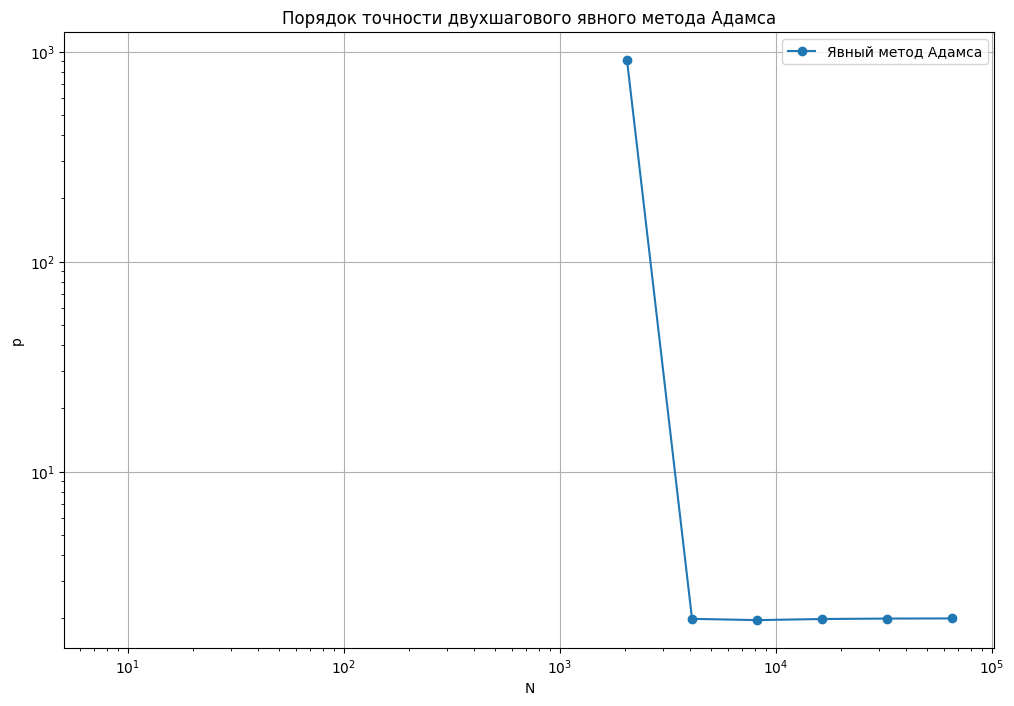

In [35]:
plt.figure(figsize=(12, 8))
plt.loglog(N, p_adams_exp_2, marker='o', label="Явный метод Адамса")
plt.title("Порядок точности двухшагового явного метода Адамса")
plt.xlabel("N")
plt.ylabel("p")
plt.grid()
plt.legend()
plt.show()

### Неявный метод Адамса (Метод Адамса - Моултона)

Выводится из тех же соображений, что и явный метод, с той лишь разницей, что степень полинома равна $M+1$

$$L_M(x) = \sum_{k=j}^{j-M}f_k \frac{(x-x_{j+1})...(x-x_{k+1})(x-x_{k-1})...(x-x_j-M)}{(x_k-x_{j+1})...(x_k-x_{k+1})(x_k-x_{k-1})...(x_k-x_{j-M})} \Longrightarrow$$


$$\Longrightarrow y_{j+1} = y_j + \frac{h}{12}(5f_{j+1} + 8f_j - f_{j-1})$$

In [36]:
def adams_implicit_2(t_j, y_j, y_jm1, h, f, Lambda):
    numerator = y_j + h/12 * (8 * Lambda * y_j - Lambda * y_jm1)
    denominator = 1 - 5 * h * Lambda / 12
    return numerator / denominator

In [37]:
errors_adams_imp_2 = []

for n in N:
    domain, h = grid(a, b, n)

    values_adams_imp_2 = [y0]

    y1 = power_series_method_2(domain[0], values_adams_imp_2[0], h, f)
    values_adams_imp_2.append(y1)

    values_analytic = [
        analytic_solution(y0, Lambda, domain[0], domain[0]),
        analytic_solution(y0, Lambda, domain[0], domain[1])
    ]

    for j in range(1, len(domain) - 1):
        y_next = adams_implicit_2(
            domain[j],
            values_adams_imp_2[j],
            values_adams_imp_2[j - 1],
            h,
            f,
            Lambda
        )
        values_adams_imp_2.append(y_next)

        values_analytic.append(
            analytic_solution(y0, Lambda, domain[0], domain[j + 1])
        )

    errors_adams_imp_2.append(inaccuracy(values_analytic, values_adams_imp_2))

In [38]:
p_adams_imp_2 = [np.nan]

for i in range(1, len(errors_adams_imp_2)):
    p_adams_imp_2.append(np.log2(errors_adams_imp_2[i - 1] / errors_adams_imp_2[i]))

In [39]:
df_adams_imp_2 = pd.DataFrame({
    "N": N,
    "eps_adams_imp_2": errors_adams_imp_2,
    "p_adams_imp_2": p_adams_imp_2
})

df_adams_imp_2

,N,eps_adams_imp_2,p_adams_imp_2
0,4,5.857094e+06,NaN
1,8,1.150165e+07,-0.973584
2,16,1.445684e+08,-3.651839
3,32,4.066264e+10,-8.135808
4,64,5.407685e+14,-13.699020
5,128,1.935539e+18,-11.805437
6,256,1.395221e+06,40.335379
7,512,4.395377e+01,14.954147
8,1024,7.308581e+00,2.588324
9,2048,1.081381e+00,2.756716


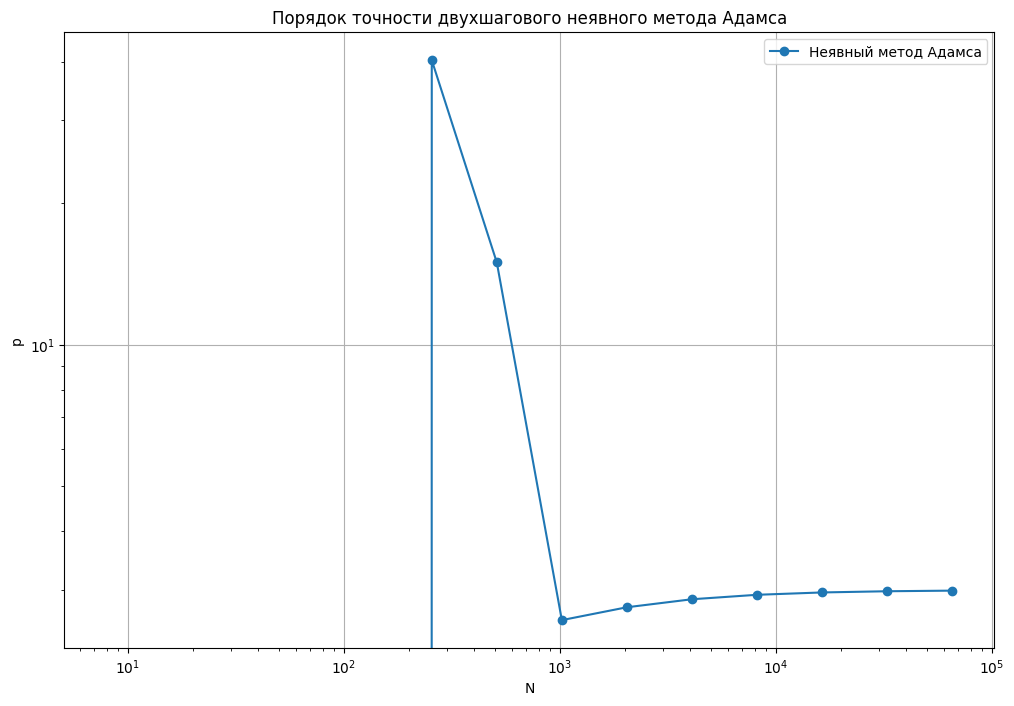

In [40]:
plt.figure(figsize=(12, 8))
plt.loglog(N, p_adams_imp_2, marker='o', label="Неявный метод Адамса")
plt.title("Порядок точности двухшагового неявного метода Адамса")
plt.xlabel("N")
plt.ylabel("p")
plt.grid()
plt.legend()
plt.show()

### Метод предиктора - корректора (Метод Адамса - Бошфорта - Моултона)

1) Используя начальное условие $y(a) = y_a$ используя один из одношаговых методов (к приемру, метод степенного ряда) вычислим значения функции $f_j$ в узлах сетки $x_1, x_2, x_3$
2) Для узлов $x_j , j \geq 3$ осуществим расчет по формуле неявного метода Адамса 
3) Приближенное решение на $n$-ой итерации обозначим за $y^n_{j+1}$, начальное же приближение для итерационного метода вычислим по явному методу Адамса четвертого порядка: $$y^0_{j+1} = y_j + \frac{h}{24}(55f_j - 59f_{j-1} + 37f_{j-2} - 9f_{j-3})$$

Так мы задали прогноз (предиктор)

На этапе коррекции (корректора) мы проводим итерационное уточнение по формулам неявного метода Адамса.  

Итерационный процесс прекращается при выполнении условия: $$|y_{j+1}^n - y_{j+1}^{n-1}| < \varepsilon$$

В результате полагаем, что: $$y_{j+1} = y_{j+1}^n$$

In [41]:
def adams_predictor_corrector(t_j, y_j, y_jm1, y_jm2, y_jm3, h, f, eps=1e-10, max_iter=100):
    f_j = f(t_j, y_j)
    f_jm1 = f(t_j - h, y_jm1)
    f_jm2 = f(t_j - 2 * h, y_jm2)
    f_jm3 = f(t_j - 3 * h, y_jm3)

    # Предиктор
    y_pred = y_j + h / 24 * (55 * f_j - 59 * f_jm1 + 37 * f_jm2 - 9 * f_jm3)

    # Корректор
    y_prev = y_pred

    for _ in range(max_iter):
        y_next = y_j + h / 24 * (
            9 * f(t_j + h, y_prev) + 19 * f_j - 5 * f_jm1 + f_jm2
        )

        if abs(y_next - y_prev) < eps:
            return y_next

        y_prev = y_next

    return y_prev

In [42]:
errors_adams_pc = []

for n in N:
    domain, h = grid(a, b, n)

    values_adams_pc = [y0]

    # стартовые значения y1, y2, y3
    for k in range(1, 4):
        values_adams_pc.append(
            power_series_method_3(domain[k - 1], values_adams_pc[k - 1], h, f)
        )

    values_analytic = [
        analytic_solution(y0, Lambda, domain[0], domain[0]),
        analytic_solution(y0, Lambda, domain[0], domain[1]),
        analytic_solution(y0, Lambda, domain[0], domain[2]),
        analytic_solution(y0, Lambda, domain[0], domain[3]),
    ]

    for j in range(3, len(domain) - 1):
        y_next = adams_predictor_corrector(
            domain[j],
            values_adams_pc[j],
            values_adams_pc[j - 1],
            values_adams_pc[j - 2],
            values_adams_pc[j - 3],
            h,
            f
        )

        values_adams_pc.append(y_next)

        values_analytic.append(
            analytic_solution(y0, Lambda, domain[0], domain[j + 1])
        )

    errors_adams_pc.append(inaccuracy(values_analytic, values_adams_pc))

In [43]:
p_adams_pc = [np.nan]

for i in range(1, len(errors_adams_pc)):
    p_adams_pc.append(np.log2(errors_adams_pc[i - 1] / errors_adams_pc[i]))

C:\Users\Cyber Kanojo\AppData\Local\Temp\ipykernel_7160\3018299421.py:4: RuntimeWarning: divide by zero encountered in log2
  p_adams_pc.append(np.log2(errors_adams_pc[i - 1] / errors_adams_pc[i]))
C:\Users\Cyber Kanojo\AppData\Local\Temp\ipykernel_7160\3018299421.py:4: RuntimeWarning: invalid value encountered in scalar divide
  p_adams_pc.append(np.log2(errors_adams_pc[i - 1] / errors_adams_pc[i]))


In [44]:
df_adams_pc = pd.DataFrame({
    "N": N,
    "eps_adams_pc": errors_adams_pc,
    "p_adams_pc": p_adams_pc
})

df_adams_pc

,N,eps_adams_pc,p_adams_pc
0,4,1.952829e+244,NaN
1,8,inf,-inf
2,16,inf,NaN
3,32,inf,NaN
4,64,inf,NaN
5,128,inf,NaN
6,256,inf,NaN
7,512,inf,NaN
8,1024,3.150463e+00,inf
9,2048,2.259990e-01,3.801176


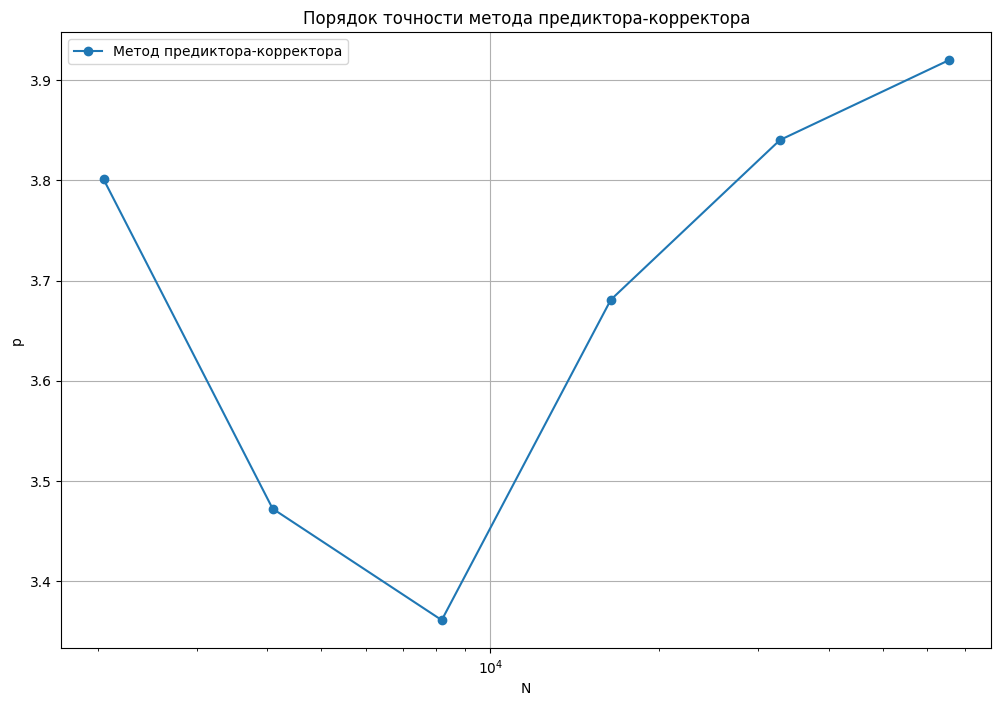

In [45]:
plt.figure(figsize=(12, 8))
plt.semilogx(N, p_adams_pc, marker='o', label="Метод предиктора-корректора")
plt.title("Порядок точности метода предиктора-корректора")
plt.xlabel("N")
plt.ylabel("p")
plt.grid()
plt.legend()
plt.show()

### Метод Гирра

Метод Гирра - один из чисто неявных методов, известных как **ФДН - формулы дифференцирования назад**. Их общий вид: $$\sum_{k=0}^{m}a_k y_{j-k} = hf(t_j, y_j)$$

Тогда метод Гира третьего порядка для задачи $y' = \lambda y$:
$$y_{j+1} = \frac{(18y_{j} - 9y_{j-1} + 2y_{j-2})}{11 - 6h \lambda}$$

In [46]:
def gear_method_3(t_j, y_j, y_jm1, y_jm2, h, Lambda):
    numerator = 18 * y_j - 9 * y_jm1 + 2 * y_jm2
    denominator = 11 - 6 * h * Lambda
    return numerator / denominator

In [47]:
errors_gear_3 = []
Lambda = -500
for n in N:
    domain, h = grid(a, b, n)

    values_gear_3 = [y0]

    # стартовые значения y1, y2
    for k in range(1, 3):
        values_gear_3.append(
            power_series_method_3(domain[k - 1], values_gear_3[k - 1], h, f)
        )

    values_analytic = [
        analytic_solution(y0, Lambda, domain[0], domain[0]),
        analytic_solution(y0, Lambda, domain[0], domain[1]),
        analytic_solution(y0, Lambda, domain[0], domain[2]),
    ]

    for j in range(2, len(domain) - 1):
        y_next = gear_method_3(
            domain[j],
            values_gear_3[j],
            values_gear_3[j - 1],
            values_gear_3[j - 2],
            h,
            Lambda
        )

        values_gear_3.append(y_next)

        values_analytic.append(
            analytic_solution(y0, Lambda, domain[0], domain[j + 1])
        )

    errors_gear_3.append(inaccuracy(values_analytic, values_gear_3))

In [48]:
p_gear_3 = [np.nan]

for i in range(1, len(errors_gear_3)):
    p_gear_3.append(np.log2(errors_gear_3[i - 1] / errors_gear_3[i]))

In [49]:
df_gear_3 = pd.DataFrame({
    "N": N,
    "eps_gear_3": errors_gear_3,
    "p_gear_3": p_gear_3
})

df_gear_3

,N,eps_gear_3,p_gear_3
0,4,2.814592e+24,NaN
1,8,4.395882e+22,6.000629
2,16,6.862574e+20,6.001259
3,32,1.070408e+19,6.002517
4,64,1.666689e+17,6.005032
5,128,2.586115e+15,6.010055
6,256,3.984969e+13,6.020074
7,512,6.056236e+11,6.040003
8,1024,8.956095e+09,6.079408
9,2048,1.255719e+08,6.156285


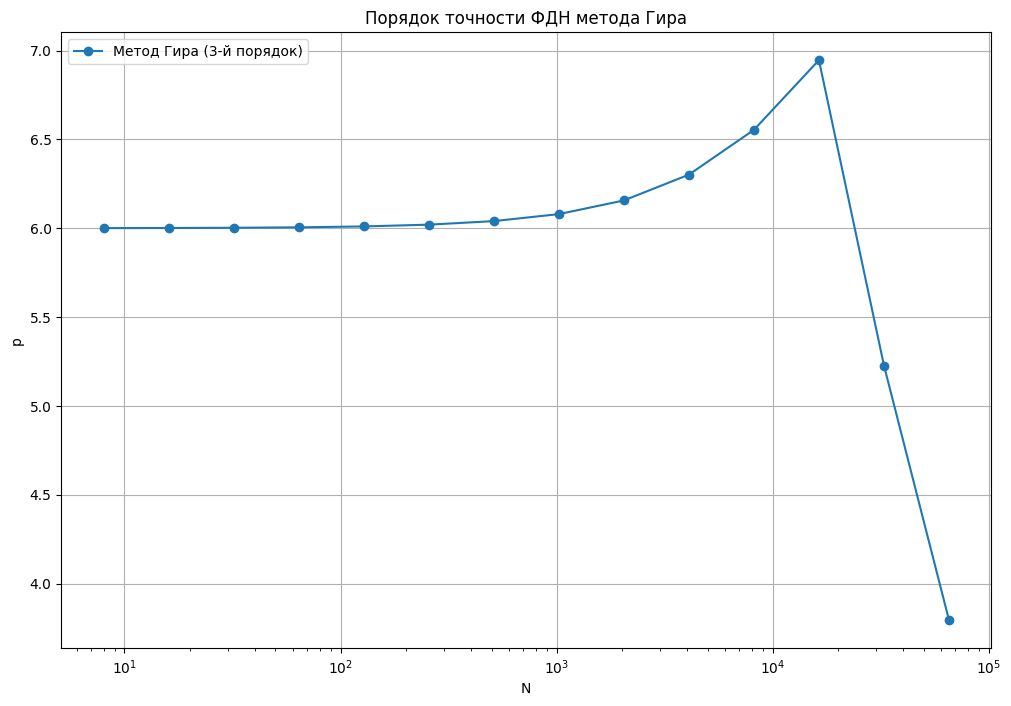

In [50]:
plt.figure(figsize=(12, 8))
plt.semilogx(N, p_gear_3, marker='o', label="Метод Гира (3-й порядок)")
plt.title("Порядок точности ФДН метода Гира")
plt.xlabel("N")
plt.ylabel("p")
plt.grid()
plt.legend()
plt.show()

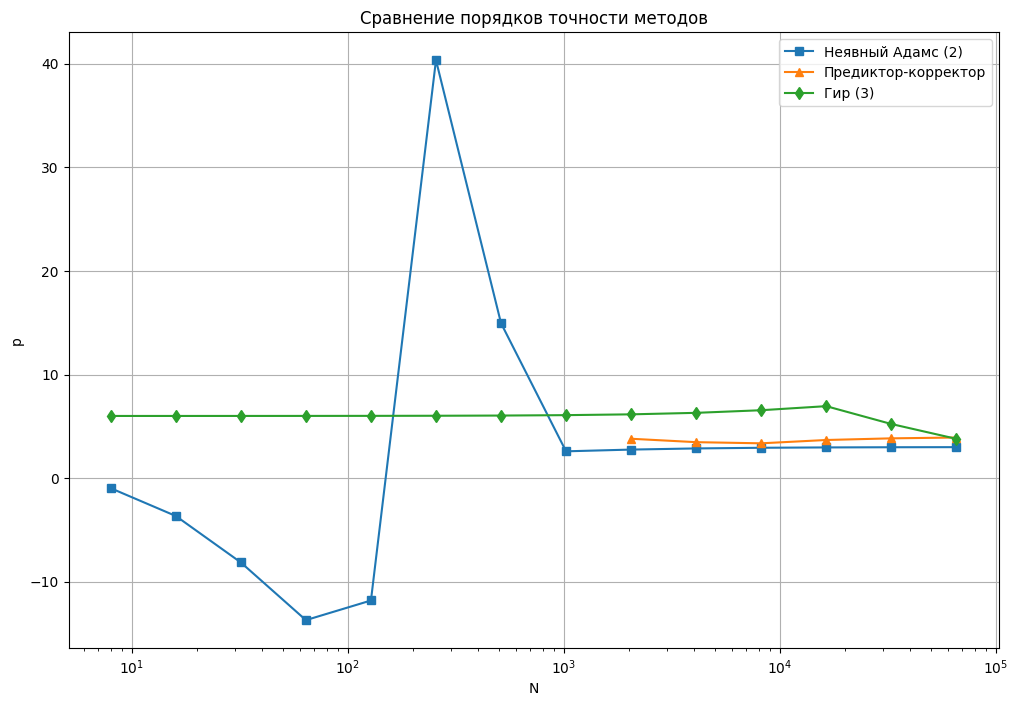

In [51]:
plt.figure(figsize=(12, 8))

#plt.semilogx(N, p_adams_exp_2, marker='o', label="Явный Адамс (2)")
plt.semilogx(N, p_adams_imp_2, marker='s', label="Неявный Адамс (2)")
plt.semilogx(N, p_adams_pc, marker='^', label="Предиктор-корректор")
plt.semilogx(N, p_gear_3, marker='d', label="Гир (3)")

plt.title("Сравнение порядков точности методов")
plt.xlabel("N")
plt.ylabel("p")

plt.grid()
plt.legend()
plt.show()

### Решение СОДУ

Рассмотрим систему:  

$$
\begin{cases}
y_1' = y_2 \\
y_2' = -y_1
\end{cases}
$$

с начальными условиями:  


$$
\begin{cases}
y_1(0) = 1 \\
y_2(0) = 0
\end{cases}
$$

Это система гармонического осциллятора.

Точное решение имеет вид:  

$$
\begin{cases}
y_1(t) = cos(t) \\
y_2(t) = -sin(t)
\end{cases}
$$

Действительно:  

$$
\begin{cases}
y_1'(t) = -sin(t) = y_2(t) \\
y_2'(t) = -cos(t) = -y_1(t)
\end{cases}
$$

Для численного решения системы используем метод Рунге–Кутты 4-го порядка.

In [116]:
a_sys = 0
b_sys = 10

Y0_sys = np.array([1.0, 0.0], dtype=float)

N_sys = [4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096, 8192]
N_ref = max(N_sys)

A_sys = np.array([[0.0, 1.0], [-1.0, 0.0]], dtype=float)
I_sys = np.eye(2)

In [117]:
def F_system(t, Y):
    y1, y2 = Y
    return np.array([y2, -y1], dtype=float)


def analytic_solution_system(t):
    return np.array([np.cos(t), -np.sin(t)], dtype=float)

In [118]:
def inaccuracy_system(analytic_values, numerical_values):
    max_error = 0.0

    for y_exact, y_num in zip(analytic_values, numerical_values):
        error = np.linalg.norm(y_exact - y_num, ord=np.inf)
        max_error = max(max_error, error)

    return max_error

In [119]:
def reference_inaccuracy_system(reference_values, coarse_values, stride):
    max_error = 0.0

    for i, y_num in enumerate(coarse_values):
        y_ref = reference_values[i * stride]
        error = np.linalg.norm(y_ref - y_num, ord=np.inf)
        max_error = max(max_error, error)

    return max_error

In [120]:
def runge_estimate_system(solution_coarse, solution_fine, p):
    max_diff = 0.0

    for i, y_coarse in enumerate(solution_coarse):
        y_fine = solution_fine[2 * i]
        diff = np.linalg.norm(y_fine - y_coarse, ord=np.inf)
        max_diff = max(max_diff, diff)

    return max_diff / (2**p - 1)

In [121]:
def experimental_orders(errors):
    p = [np.nan]
    for i in range(1, len(errors)):
        if errors[i] == 0 or errors[i-1] == 0:
            p.append(np.nan)
        else:
            p.append(np.log2(errors[i - 1] / errors[i]))
    return p

In [122]:
def runge_orders(runge_errors):
    p = [np.nan]
    for i in range(1, len(runge_errors)):
        if np.isnan(runge_errors[i - 1]) or np.isnan(runge_errors[i]) or runge_errors[i] == 0:
            p.append(np.nan)
        else:
            p.append(np.log2(runge_errors[i - 1] / runge_errors[i]))
    return p

In [123]:
def adams_explicit_2_system(t_j, Y_j, Y_jm1, h, F):
    F_j = F(t_j, Y_j)
    F_jm1 = F(t_j - h, Y_jm1)
    return Y_j + h / 2 * (3 * F_j - F_jm1)

In [124]:
def adams_implicit_2_system(Y_j, Y_jm1, h):
    rhs = Y_j + h / 12 * (8 * (A_sys @ Y_j) - (A_sys @ Y_jm1))
    lhs = I_sys - (5 * h / 12) * A_sys
    return np.linalg.solve(lhs, rhs)

In [125]:
def adams_predictor_corrector_system(t_j, Y_j, Y_jm1, Y_jm2, Y_jm3, h, F, eps=1e-10, max_iter=100):
    F_j = F(t_j, Y_j)
    F_jm1 = F(t_j - h, Y_jm1)
    F_jm2 = F(t_j - 2 * h, Y_jm2)
    F_jm3 = F(t_j - 3 * h, Y_jm3)

    Y_pred = Y_j + h / 24 * (55 * F_j - 59 * F_jm1 + 37 * F_jm2 - 9 * F_jm3)

    Y_prev = Y_pred

    for _ in range(max_iter):
        Y_next = Y_j + h / 24 * (
            9 * F(t_j + h, Y_prev) + 19 * F_j - 5 * F_jm1 + F_jm2
        )

        if np.linalg.norm(Y_next - Y_prev, ord=np.inf) < eps:
            return Y_next

        Y_prev = Y_next

    return Y_prev

In [126]:
def gear_method_3_system(Y_j, Y_jm1, Y_jm2, h):
    rhs = 18 * Y_j - 9 * Y_jm1 + 2 * Y_jm2
    lhs = 11 * I_sys - 6 * h * A_sys
    return np.linalg.solve(lhs, rhs)

In [127]:
def solve_system_method(method_name, N_values):
    solutions = {}
    exact_errors = []

    for n in N_values:
        domain, h = grid(a_sys, b_sys, n)

        if method_name in ["adams_explicit_2", "adams_implicit_2"]:
            values = [
                analytic_solution_system(domain[0]),
                analytic_solution_system(domain[1])
            ]

            for j in range(1, len(domain) - 1):
                if method_name == "adams_explicit_2":
                    Y_next = adams_explicit_2_system(
                        domain[j],
                        values[j],
                        values[j - 1],
                        h,
                        F_system
                    )
                else:
                    Y_next = adams_implicit_2_system(
                        values[j],
                        values[j - 1],
                        h
                    )

                values.append(Y_next)

        elif method_name == "adams_pc":
            values = [
                analytic_solution_system(domain[0]),
                analytic_solution_system(domain[1]),
                analytic_solution_system(domain[2]),
                analytic_solution_system(domain[3])
            ]

            for j in range(3, len(domain) - 1):
                Y_next = adams_predictor_corrector_system(
                    domain[j],
                    values[j],
                    values[j - 1],
                    values[j - 2],
                    values[j - 3],
                    h,
                    F_system
                )
                values.append(Y_next)

        elif method_name == "gear_3":
            values = [
                analytic_solution_system(domain[0]),
                analytic_solution_system(domain[1]),
                analytic_solution_system(domain[2])
            ]

            for j in range(2, len(domain) - 1):
                Y_next = gear_method_3_system(
                    values[j],
                    values[j - 1],
                    values[j - 2],
                    h
                )
                values.append(Y_next)

        analytic_values = [analytic_solution_system(t) for t in domain]

        solutions[n] = {
            "domain": domain,
            "values": values
        }

        exact_errors.append(inaccuracy_system(analytic_values, values))

    return solutions, exact_errors

In [128]:
solutions_adams_exp_2_sys, exact_adams_exp_2_sys = solve_system_method("adams_explicit_2", N_sys)
solutions_adams_imp_2_sys, exact_adams_imp_2_sys = solve_system_method("adams_implicit_2", N_sys)
solutions_adams_pc_sys, exact_adams_pc_sys = solve_system_method("adams_pc", N_sys)
solutions_gear_3_sys, exact_gear_3_sys = solve_system_method("gear_3", N_sys)

In [129]:
def build_system_table(solutions, exact_errors, N_values, p_method):
    ref_values = solutions[N_ref]["values"]

    eps_ref = []
    eps_runge = [np.nan]

    for i, n in enumerate(N_values):
        values = solutions[n]["values"]

        stride = N_ref // n
        eps_ref.append(reference_inaccuracy_system(ref_values, values, stride))

        if i > 0:
            n_prev = N_values[i - 1]
            values_prev = solutions[n_prev]["values"]
            values_curr = solutions[n]

            eps_runge.append(
                runge_estimate_system(
                    solutions[n_prev]["values"],
                    solutions[n]["values"],
                    p_method
                )
            )

    p_exp = experimental_orders(exact_errors)
    p_runge = runge_orders(eps_runge)

    df = pd.DataFrame({
        "N": N_values,
        "eps_exact": exact_errors,
        "eps_ref": eps_ref,
        "eps_runge": eps_runge,
        "p_exp": p_exp,
        "p_runge": p_runge,
        "p_ref": experimental_orders(eps_ref)
    })

    return df

In [130]:
df_adams_exp_2_sys = build_system_table(
    solutions_adams_exp_2_sys,
    exact_adams_exp_2_sys,
    N_sys,
    p_method=2
)

df_adams_imp_2_sys = build_system_table(
    solutions_adams_imp_2_sys,
    exact_adams_imp_2_sys,
    N_sys,
    p_method=2
)

df_adams_pc_sys = build_system_table(
    solutions_adams_pc_sys,
    exact_adams_pc_sys,
    N_sys,
    p_method=4
)

df_gear_3_sys = build_system_table(
    solutions_gear_3_sys,
    exact_gear_3_sys,
    N_sys,
    p_method=3
)

In [ ]:
summary_df = pd.DataFrame({
    "N": N_sys,

    "eps_exact_AB": df_adams_exp_2_sys["eps_exact"],
    "eps_runge_AB": df_adams_exp_2_sys["eps_runge"],
    "eps_ref_AB": df_adams_exp_2_sys["eps_ref"],
    "p_AB": df_adams_exp_2_sys["p_exp"],
    "p_runge_AB": df_adams_exp_2_sys["p_runge"],
    "p_ref": df_adams_exp_2_sys["p_ref"],

    "eps_exact_AM": df_adams_imp_2_sys["eps_exact"],
    "eps_runge_AM": df_adams_imp_2_sys["eps_runge"],
    "eps_ref_AM": df_adams_imp_2_sys["eps_ref"],
    "p_AM": df_adams_imp_2_sys["p_exp"],
    "p_runge_AM": df_adams_imp_2_sys["p_runge"],
    "p_ref": df_adams_imp_2_sys["p_ref"],

    "eps_exact_PC": df_adams_pc_sys["eps_exact"],
    "eps_runge_PC": df_adams_pc_sys["eps_runge"],
    "eps_ref_PC": df_adams_pc_sys["eps_ref"],
    "p_PC": df_adams_pc_sys["p_exp"],
    "p_runge_PC": df_adams_pc_sys["p_runge"],
    "p_ref": df_adams_pc_sys["p_ref"],

    "eps_exact_Gear": df_gear_3_sys["eps_exact"],
    "eps_runge_Gear": df_gear_3_sys["eps_runge"],
    "eps_ref_Gear": df_gear_3_sys["eps_ref"],
    "p_Gear": df_gear_3_sys["p_exp"],
    "p_runge_Gear": df_gear_3_sys["p_runge"],
    "p_ref": df_gear_3_sys["p_ref"],
})

display(summary_df)

,N,eps_exact_AB,eps_runge_AB,eps_ref_AB,p_AB,p_runge_AB,eps_exact_AM,eps_runge_AM,eps_ref_AM,p_AM,...,eps_exact_PC,eps_runge_PC,eps_ref_PC,p_PC,p_runge_PC,eps_exact_Gear,eps_runge_Gear,eps_ref_Gear,p_Gear,p_runge_Gear
0,4,60.461376,NaN,60.461373,NaN,NaN,2.831835e+00,NaN,2.831835e+00,NaN,...,9.764623e-01,NaN,9.764623e-01,NaN,NaN,1.740771e+00,NaN,1.740771e+00,NaN,NaN
1,8,72.774393,44.411923,72.774396,-0.267417,NaN,7.496650e-01,8.895183e-01,7.496650e-01,1.917419,...,3.596994e-01,4.969749e-02,3.596994e-01,1.440773,NaN,1.557618e+00,2.055368e-01,1.557618e+00,0.160385,NaN
2,16,3.011877,25.090529,3.011871,4.594696,0.823804,9.346372e-02,2.187338e-01,9.346372e-02,3.003768,...,3.247199e-02,2.181516e-02,3.247199e-02,3.469524,1.187842,4.370854e-01,1.958774e-01,4.370854e-01,1.833354,0.069446
3,32,0.415105,0.866467,0.415099,2.859116,4.855854,1.183894e-02,2.745389e-02,1.183894e-02,2.980867,...,2.191868e-03,2.021523e-03,2.191868e-03,3.888963,3.431817,6.958006e-02,5.250076e-02,6.958006e-02,2.651169,1.899541
4,64,0.097519,0.106019,0.097513,2.089719,3.030817,1.488759e-03,3.451736e-03,1.488758e-03,2.991358,...,1.434056e-04,1.365641e-04,1.434056e-04,3.933988,3.887792,8.844733e-03,8.725554e-03,8.844729e-03,2.975783,2.589020
5,128,0.024111,0.024469,0.024105,2.015971,2.115288,1.872474e-04,4.338371e-04,1.872467e-04,2.991092,...,9.143433e-06,8.953528e-06,9.143432e-06,3.971221,3.930979,1.117372e-03,1.104212e-03,1.117368e-03,2.984709,2.982230
6,256,0.006021,0.006030,0.006015,2.001749,2.020674,2.347381e-05,5.459121e-05,2.347309e-05,2.995822,...,5.769453e-07,5.711435e-07,5.769448e-07,3.986229,3.970531,1.404518e-04,1.395705e-04,1.404475e-04,2.991963,2.983951
7,512,0.001505,0.001505,0.001500,1.999708,2.002287,2.938264e-06,6.845181e-06,2.937545e-06,2.998016,...,3.625508e-08,3.604676e-08,3.625452e-08,3.992179,3.985912,1.760514e-05,1.754990e-05,1.760083e-05,2.996007,2.991459
8,1024,0.000376,0.000376,0.000371,1.999619,1.999846,3.675277e-07,8.569121e-07,3.668091e-07,2.999039,...,2.283684e-09,2.264872e-09,2.283127e-09,3.988748,3.992368,2.203643e-06,2.200228e-06,2.199334e-06,2.998034,2.995738
9,2048,0.000094,0.000094,0.000088,1.999758,1.999606,4.595601e-08,1.071906e-07,4.523739e-08,2.999528,...,1.424190e-10,1.427556e-10,1.418608e-10,4.003150,3.987810,2.756410e-07,2.754295e-07,2.713318e-07,2.999028,2.997898
